In [2]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [3]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [4]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog

In [5]:
#Import data
from load_data import load_data

indep_vars, dep_vars = load_data('../AirFogSim/output/global_data.csv')

In [ ]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 3 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
"""

In [6]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehicle counts.
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot
Note: Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacity per node (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions. It shows complex oscillating behavior over time. Please consider:
- Polynomial terms (e.g., x1², x2³)
- Logarithmic or exponential structures
- Residual combinations or moving average style components

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs. It must be in the range [0, 1]. You are encouraged to use structures that naturally output bounded values, such as:
- Sigmoid: y = 1 / (1 + exp(-(…)))
- Bounded min/max: y = min(1, max(0, …))
"""

Running experiment 1...


d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:26: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  self.llm = ChatOpenAI(temperature=temp, model=model)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:36: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.equation_generation_chain = LLMChain(llm=self.llm, prompt=self.startup_promt)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:58: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will b

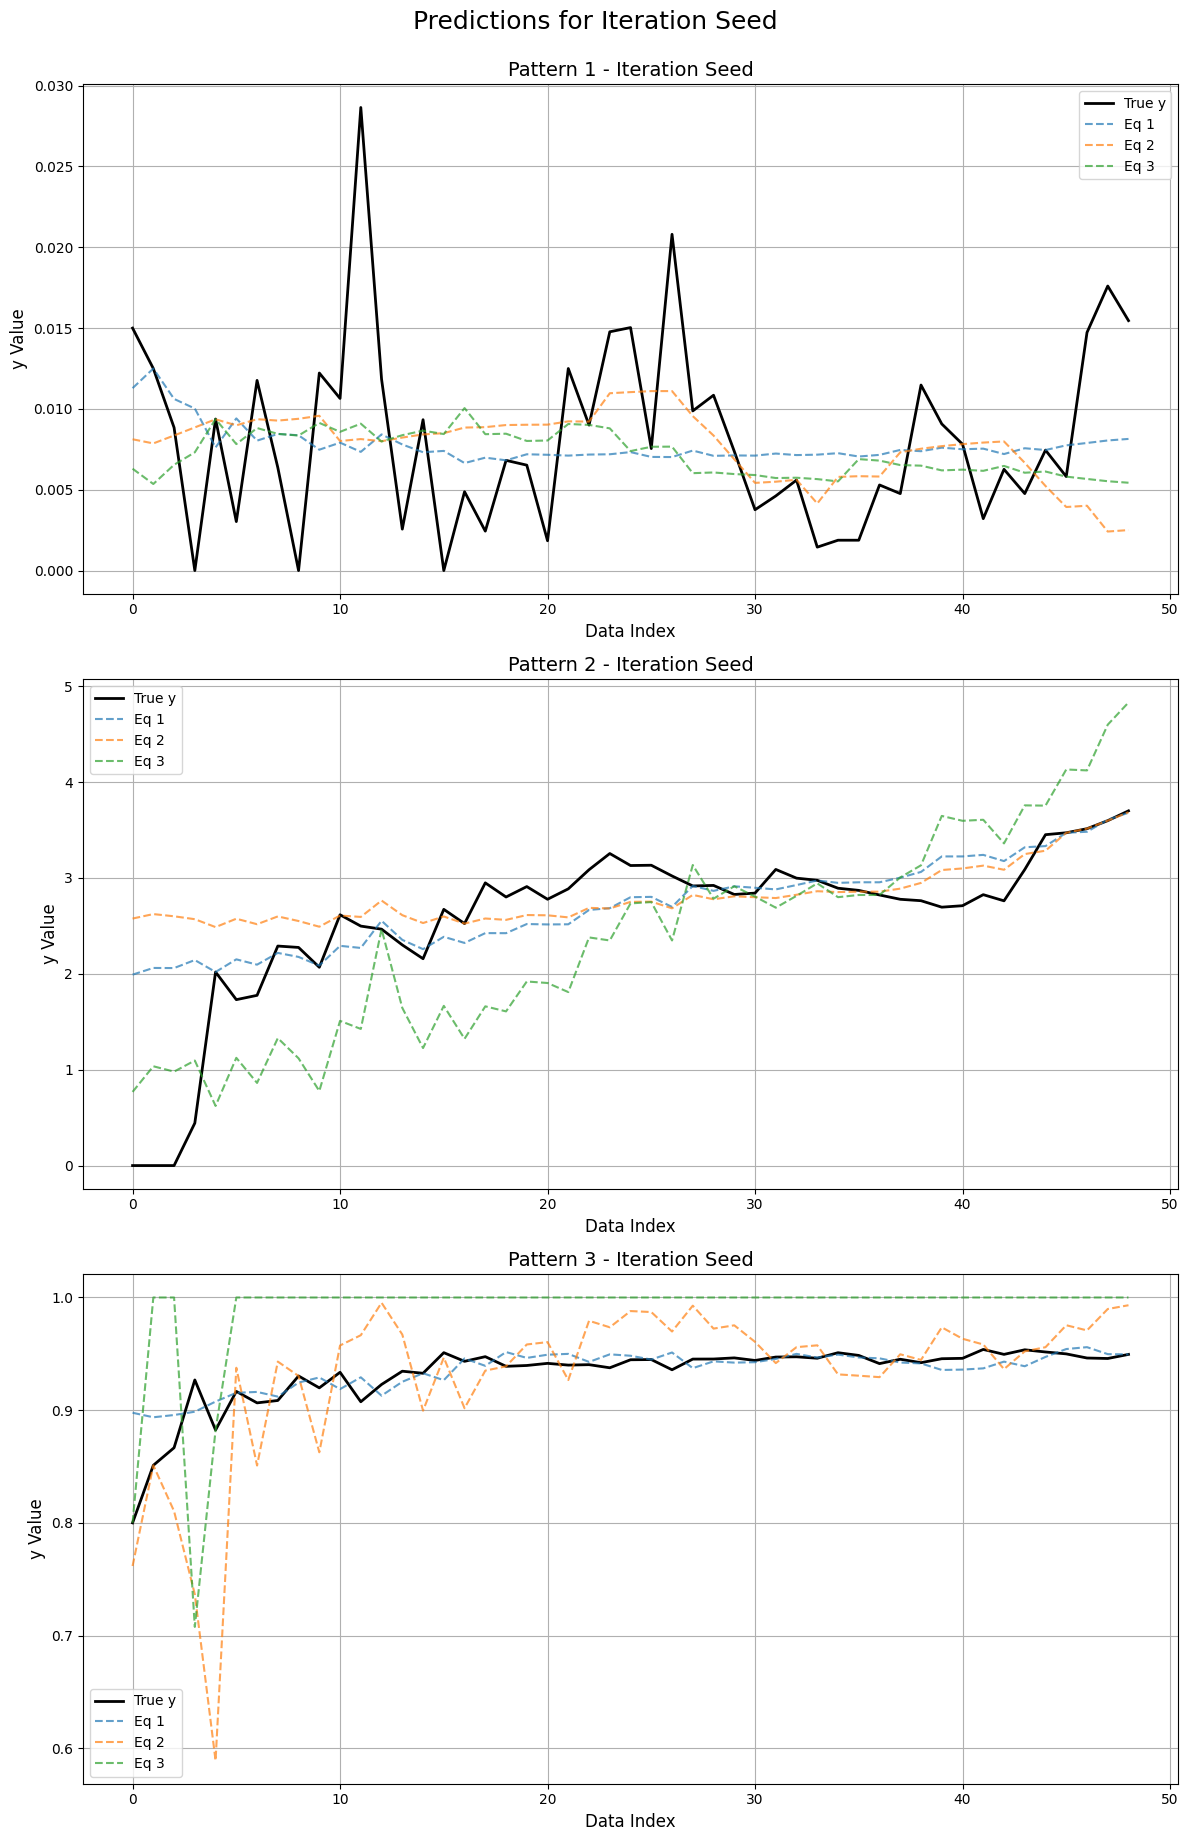

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1:
For the first pattern, we aim to predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density, and junction vehicle counts. The dataset shows that the dependent variable, compute load, has small values with somewhat oscillating behavior. 

1. Consider polynomial terms like squares and cubes of x1 (task success ratio) and x2 (vehicle density), since they are likely to have a significant impact on compute load due to their non-linear nature.

2. Logarithmic or exponential structures can help capture multiplicative relationships, especially between vehicle density and UAV density.

3. Moving average style components can incorporate temporal smoothing effects, especially for oscillating behavior.

Pattern 2:
In the second pattern, we predict the average V2U rate of the next time slot based on vehicle density, UAV density, and compute load. The

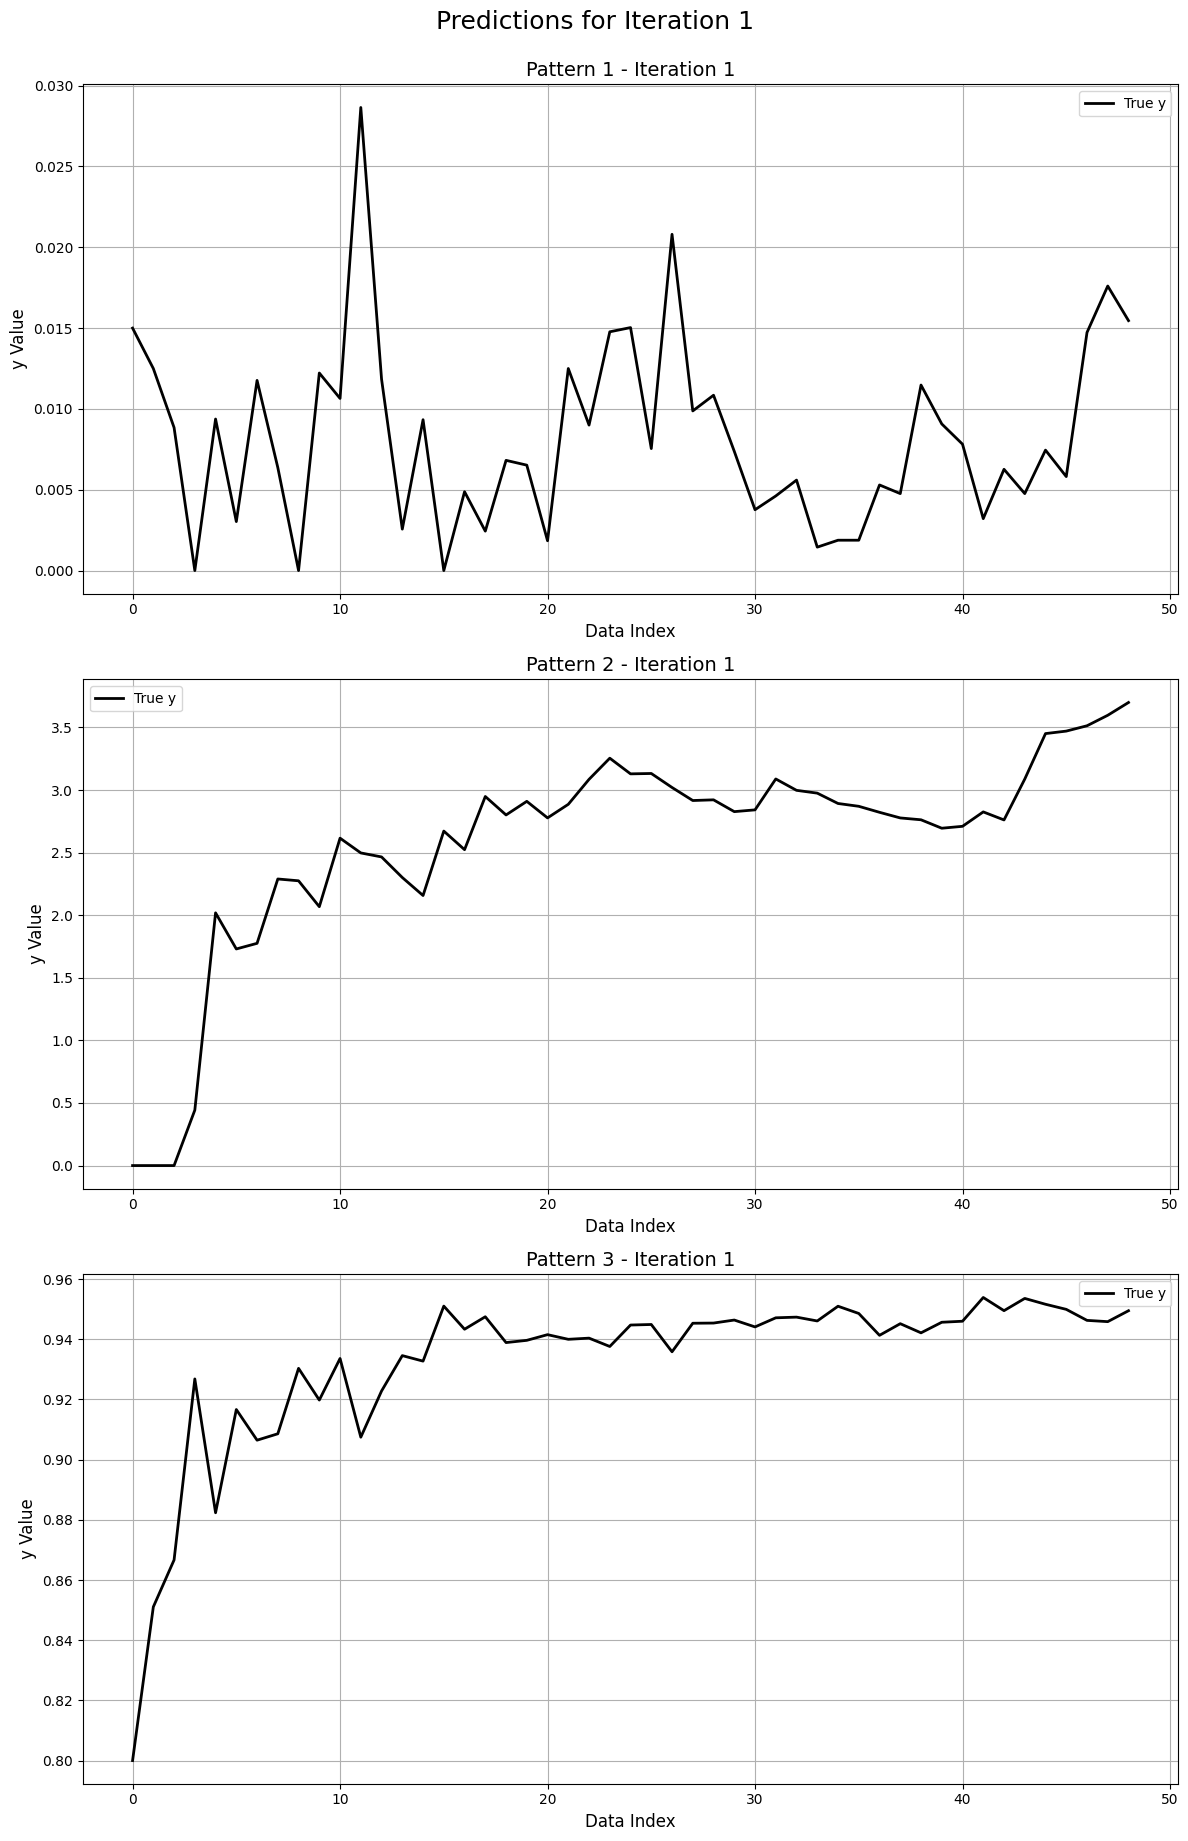

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+1)', 'complexity': 18, 'nmae': np.float64(0.1483183958636585), 'fitted_params': [-0.022310524307383554, 3.566148011206125e-06, 0.012730677518312907]}, {'equation': 'c[0]*exp(x1)+c[1]*x2+c[2]*x5', 'complexity': 12, 'nmae': np.float64(0.1490042261756937), 'fitted_params': [0.0034084681738579693, 0.0006492131878238521, -0.001563188414528075]}, {'equation': 'c[0]*x1**3+c[1]*sqrt(x2)+c[2]*x4', 'complexity': 14, 'nmae': np.float64(0.1523969345306447), 'fitted_params': [0.014167424121195388, -0.0028882999809275553, 0.0011914016765216748]}], [{'equation': 'c[0]*x1+c[1]*x2**2+c[2]*log(x3+1)', 'complexity': 16, 'nmae': np.float64(0.09642722206689106), 'fitted_params': [0.23405008452621917, 0.033804789890045914, 14.14788309514406]}, {'equation': 'c[0]*x1**3+c[1]*exp(x2)+c[2]*x3', 'complexity': 14, 'nmae': np.float64(0.11364511013585361), 'fitted_params': [0.0027887515734525596, 0.0018652223478467

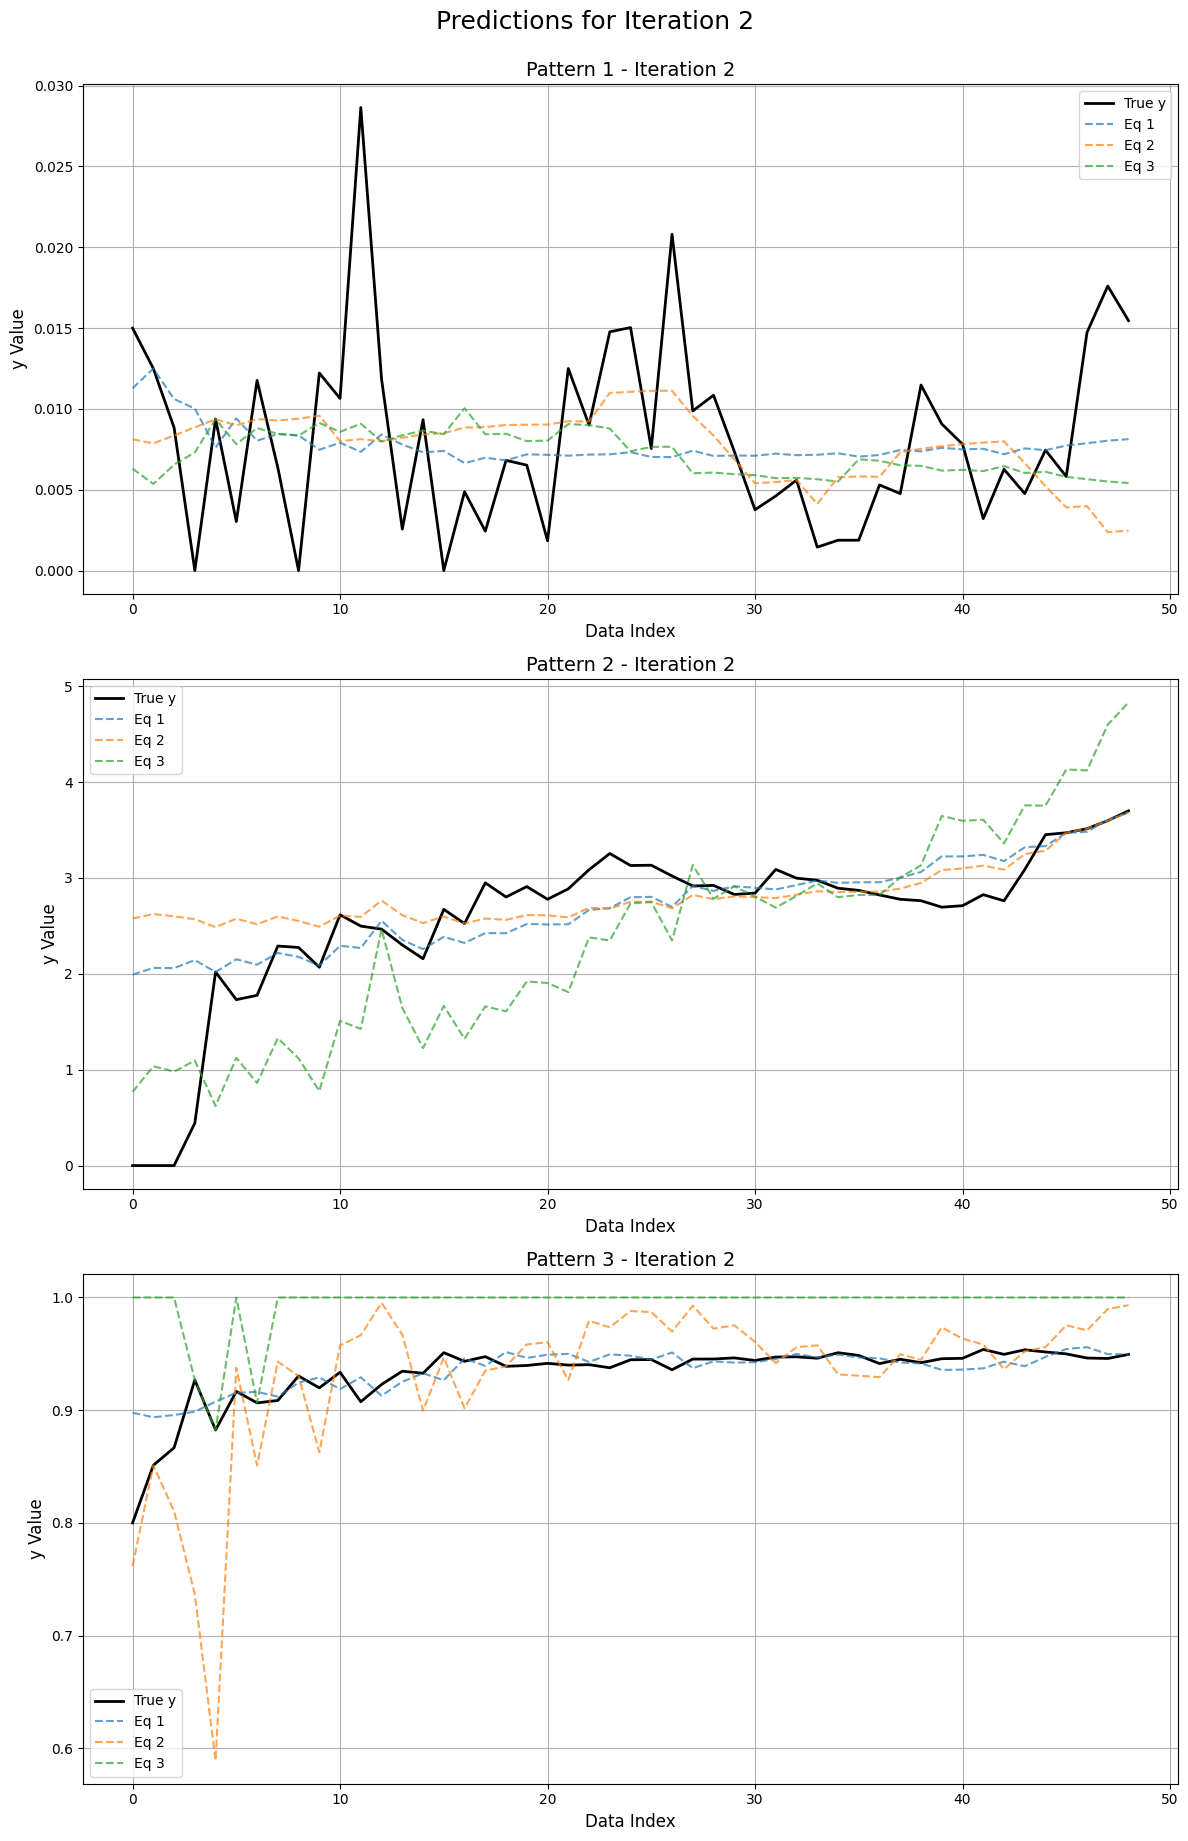

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**3+c[1]*sqrt(x2)+c[2]*x4', 'complexity': 14, 'nmae': np.float64(0.1523960100022484), 'fitted_params': [0.01418485918201549, -0.0028985768719019833, 0.001187743380235506]}, {'equation': 'c[0]*exp(x1)+c[1]*x2+c[2]*x5', 'complexity': 12, 'nmae': np.float64(0.1489989553241248), 'fitted_params': [0.003406712814667697, 0.0006561074178140862, -0.0015748451665384528]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+1)', 'complexity': 18, 'nmae': np.float64(0.1483183958636585), 'fitted_params': [-0.022310524307383554, 3.566148011206125e-06, 0.012730677518312907]}], [{'equation': 'c[0]*x1*x2+c[1]*x3', 'complexity': 9, 'nmae': np.float64(0.1855909616184834), 'fitted_params': [0.07513138955540093, 53.490002913715166]}, {'equation': 'c[0]*x1**3+c[1]*exp(x2)+c[2]*x3', 'complexity': 14, 'nmae': np.float64(0.11364510986147815), 'fitted_params': [0.002788751669895837, 0.00186522239353344, 9.318281672591464]}, {'equation': 'c[0

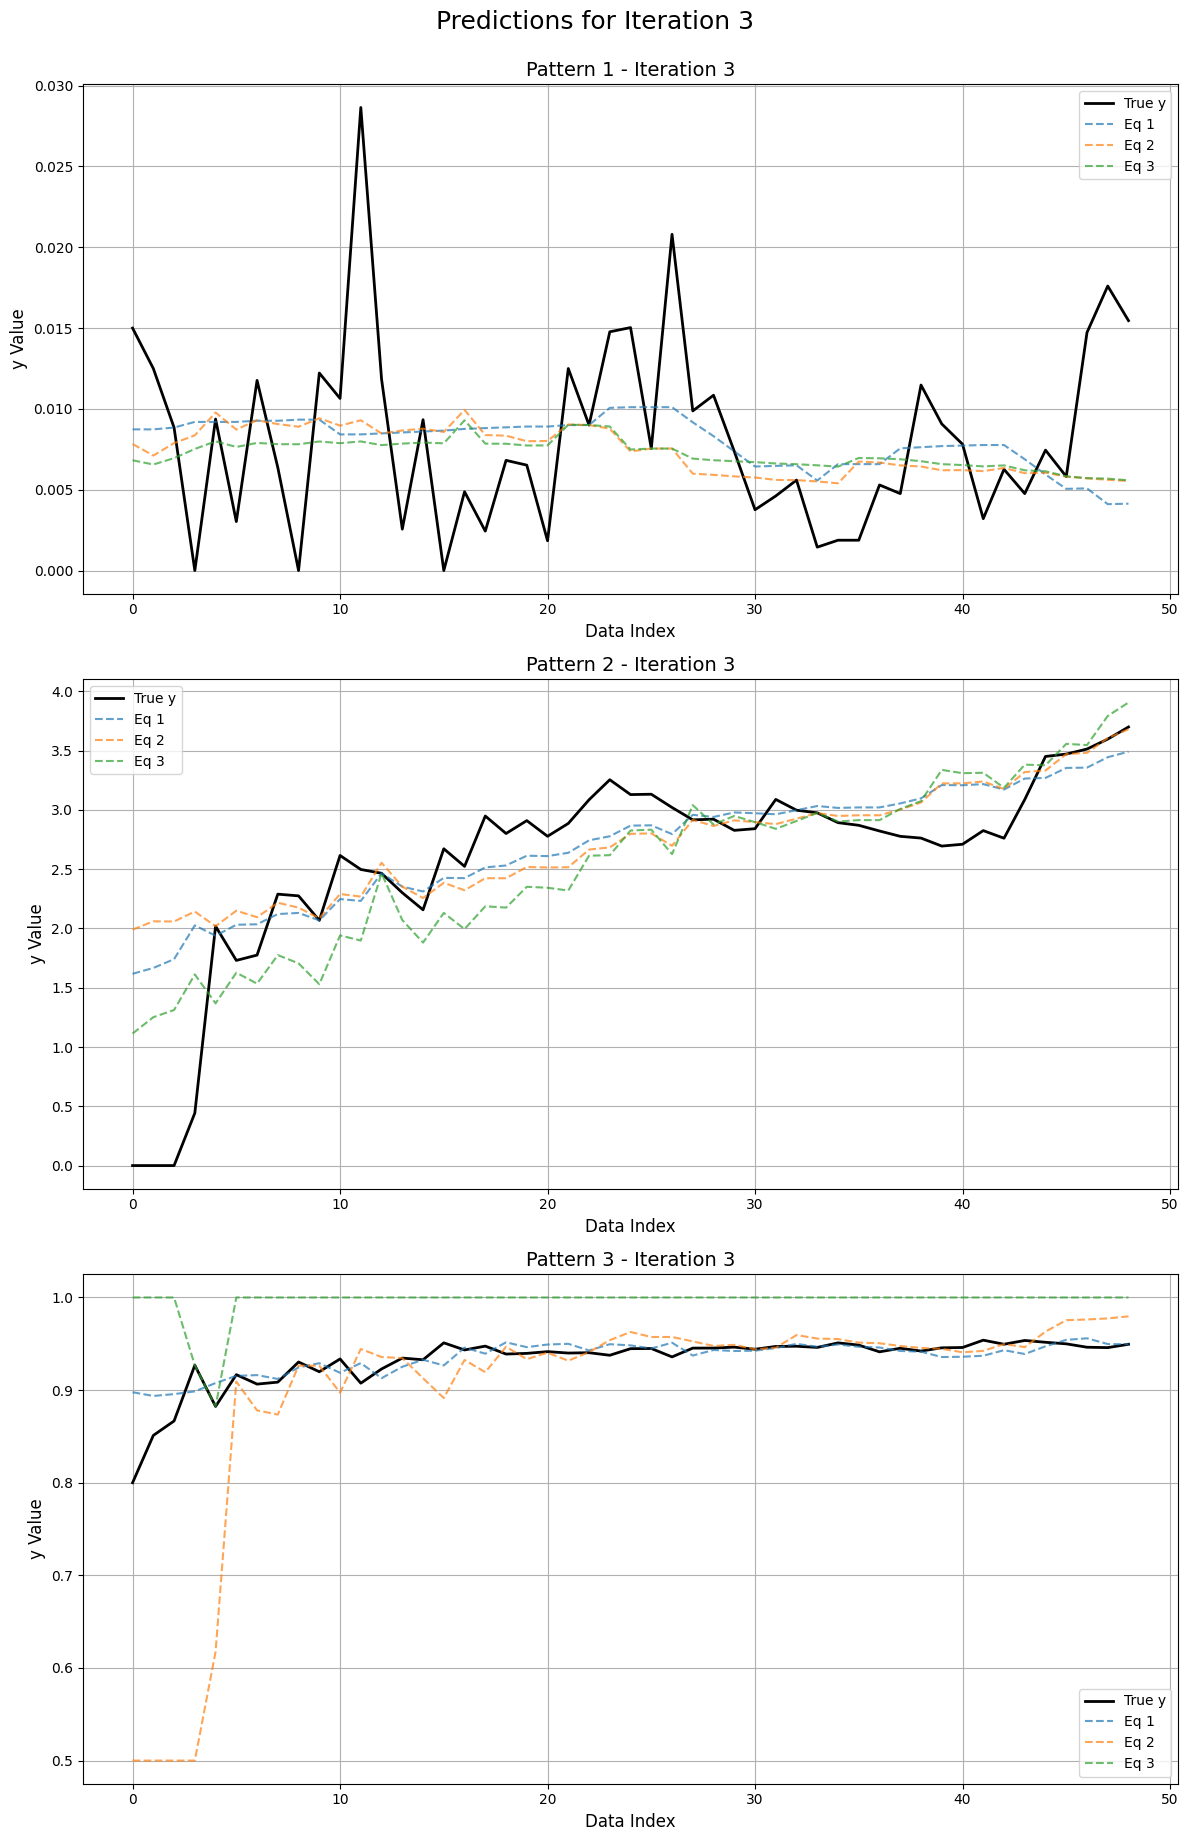

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**3+c[1]*sqrt(x2)+c[2]*x4', 'complexity': 14, 'nmae': np.float64(0.1523960100022484), 'fitted_params': [0.01418485918201549, -0.0028985768719019833, 0.001187743380235506]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x4', 'complexity': 16, 'nmae': np.float64(0.14963405318393697), 'fitted_params': [0.013091392156099363, -0.0035157845978956246, 0.0012250835551838115]}, {'equation': 'c[0]*sqrt(x2)+c[1]*x3*x5+c[2]', 'complexity': 12, 'nmae': np.float64(0.14890070262678176), 'fitted_params': [0.0011074735286562645, -0.00013584531651465162, 0.008008375025916788]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+1)', 'complexity': 18, 'nmae': np.float64(0.1483183958636585), 'fitted_params': [-0.022310524307383554, 3.566148011206125e-06, 0.012730677518312907]}], [{'equation': 'c[0]*x1*x2+c[1]*x3', 'complexity': 9, 'nmae': np.float64(0.1855909616184834), 'fitted_params': [0.07513138955540093, 53.490002913715166]}, {'equ

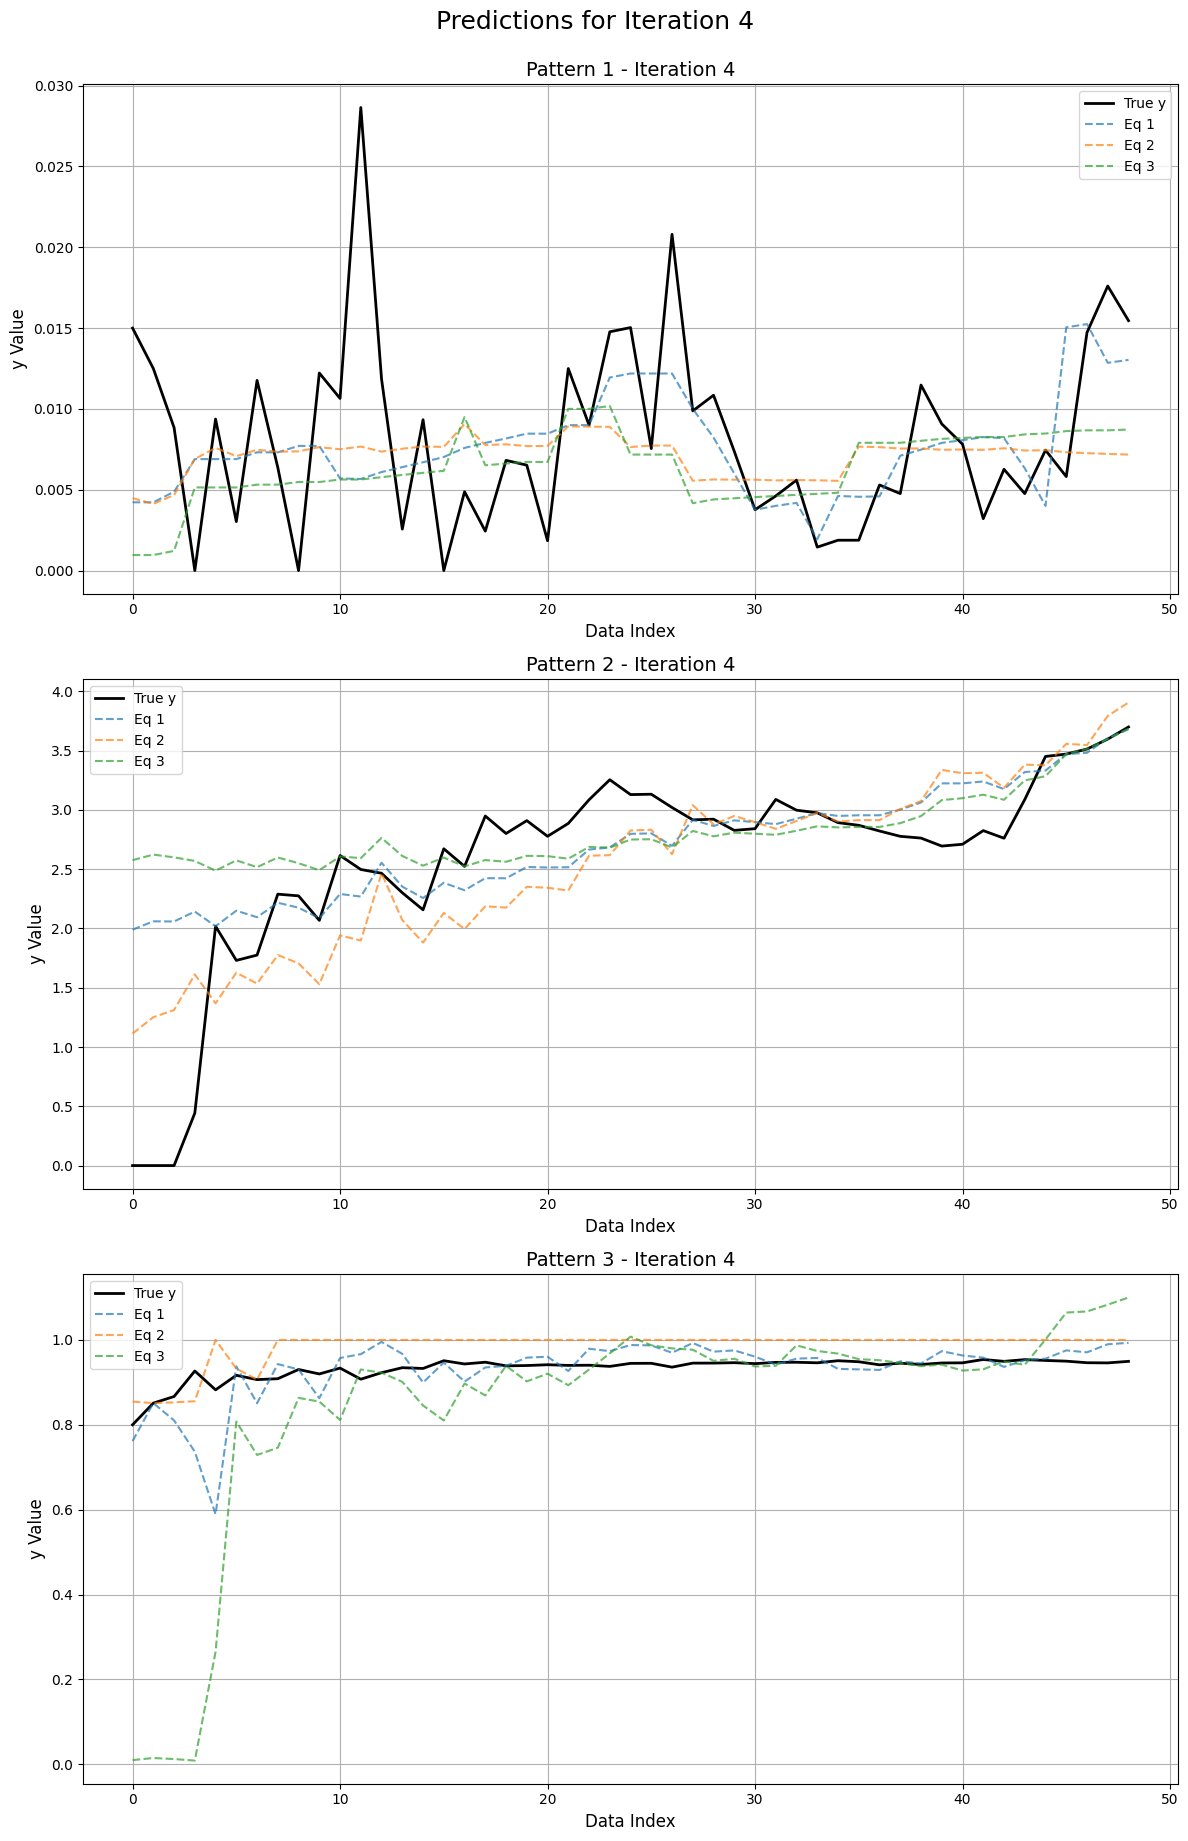

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x4', 'complexity': 16, 'nmae': np.float64(0.14963405318393697), 'fitted_params': [0.013091392156099363, -0.0035157845978956246, 0.0012250835551838115]}, {'equation': 'c[0]*sqrt(x2)+c[1]*x3*x5+c[2]', 'complexity': 12, 'nmae': np.float64(0.14890070262678176), 'fitted_params': [0.0011074735286562645, -0.00013584531651465162, 0.008008375025916788]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+1)', 'complexity': 18, 'nmae': np.float64(0.1483183958636585), 'fitted_params': [-0.022310524307383554, 3.566148011206125e-06, 0.012730677518312907]}, {'equation': 'c[0]*x1*x5+c[1]*sqrt(x2)+c[2]*x6', 'complexity': 14, 'nmae': np.float64(0.13607656240102387), 'fitted_params': [-0.002592004474754105, 0.0064281336898493364, 0.006477131051119078]}], [{'equation': 'c[0]*x1*x2+c[1]*x3', 'complexity': 9, 'nmae': np.float64(0.1855909616184834), 'fitted_params': [0.07513138955540093, 53.490002913715166]}, {'e

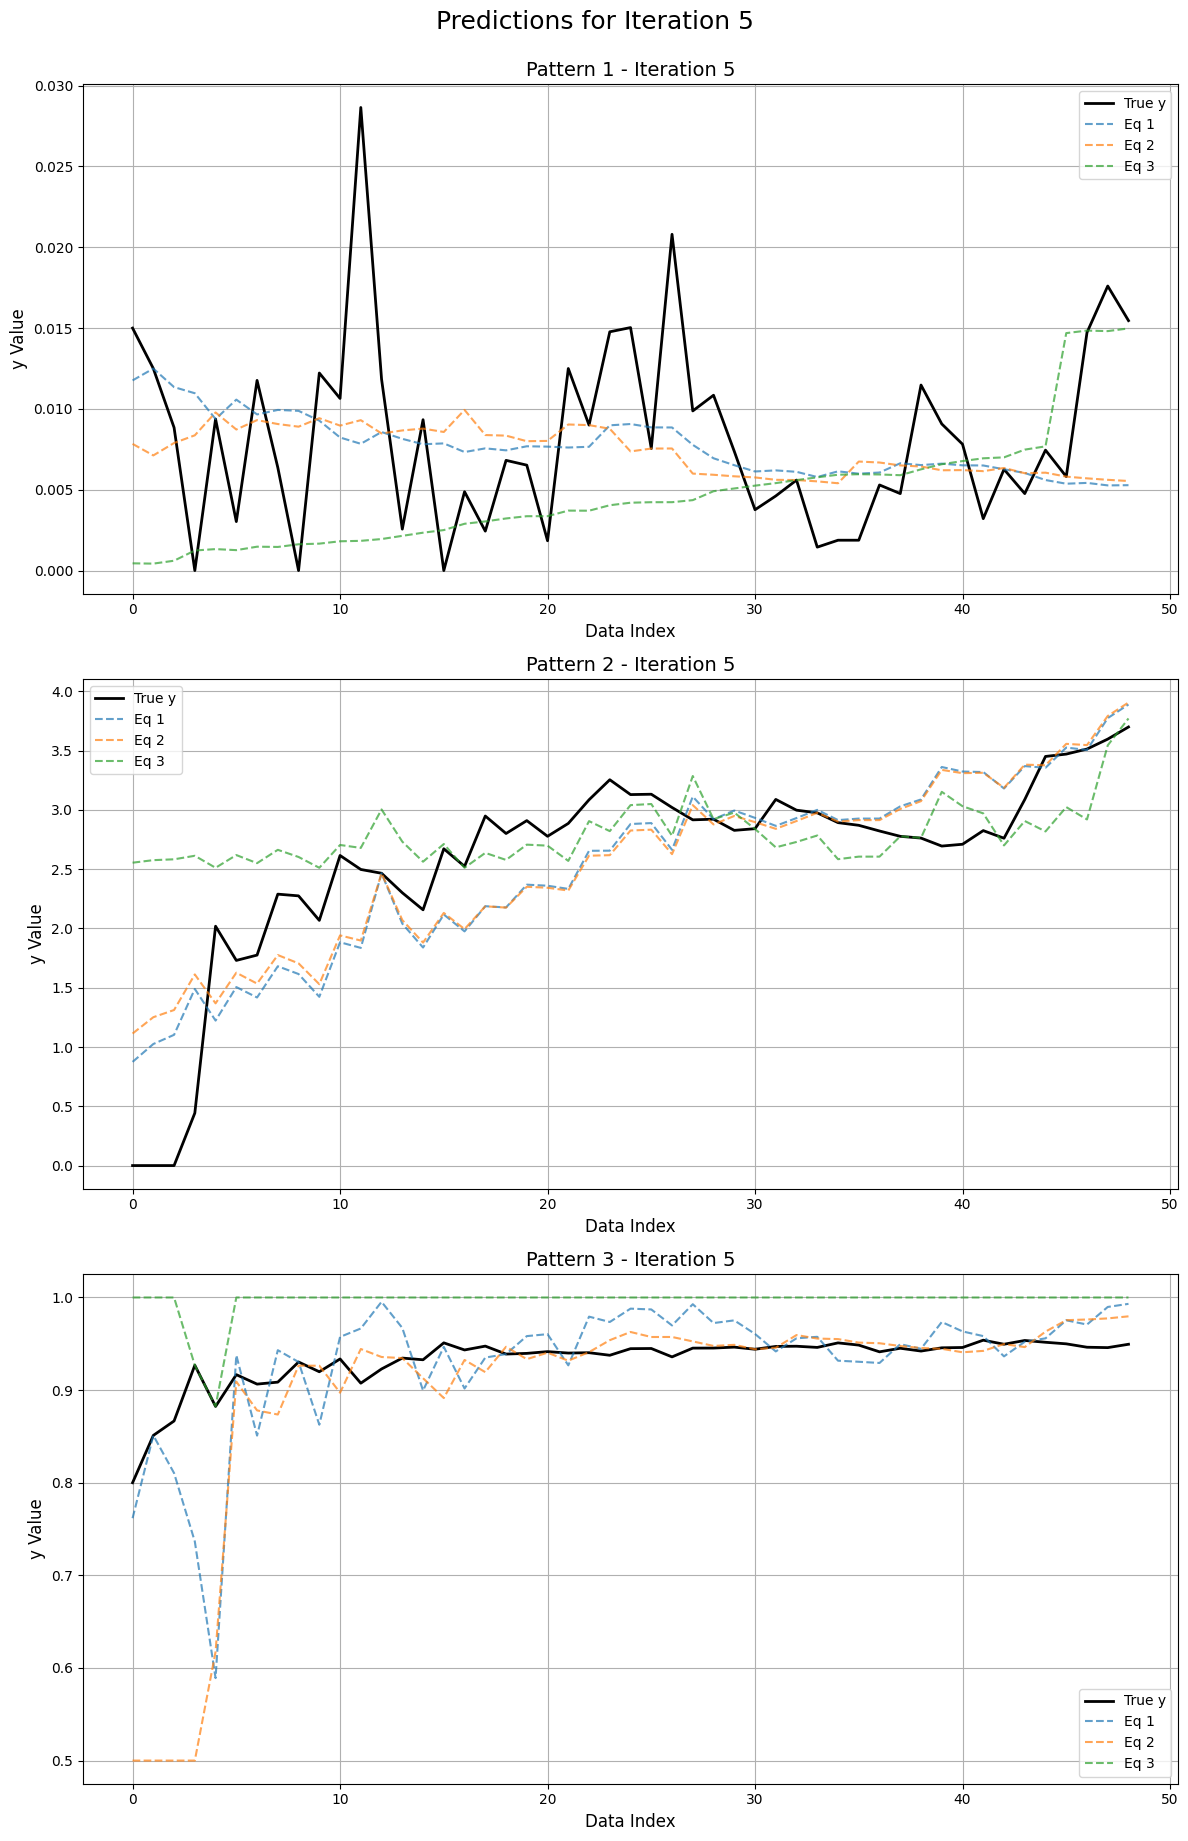

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1*x2+c[1]*x6', 'complexity': 9, 'nmae': np.float64(0.18084656161840298), 'fitted_params': [0.0012446558023221943, 0.0032553474368429485]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+1)+c[2]*x4', 'complexity': 16, 'nmae': np.float64(0.14963310592751725), 'fitted_params': [0.013104212685487393, -0.003519943749598183, 0.001221125964422453]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+1)', 'complexity': 18, 'nmae': np.float64(0.1483183958636585), 'fitted_params': [-0.022310524307383554, 3.566148011206125e-06, 0.012730677518312907]}, {'equation': 'c[0]*x1**3+c[1]*sqrt(x5)+c[2]', 'complexity': 12, 'nmae': np.float64(0.14583554871074744), 'fitted_params': [-0.01098688745856238, -0.0013391240195542986, 0.0181222827812485]}, {'equation': 'c[0]*x1*x5+c[1]*sqrt(x2)+c[2]*x6', 'complexity': 14, 'nmae': np.float64(0.13607656240102387), 'fitted_params': [-0.002592004474754105, 0.0064281336898493364, 0.006477131051119078]}], [{'e

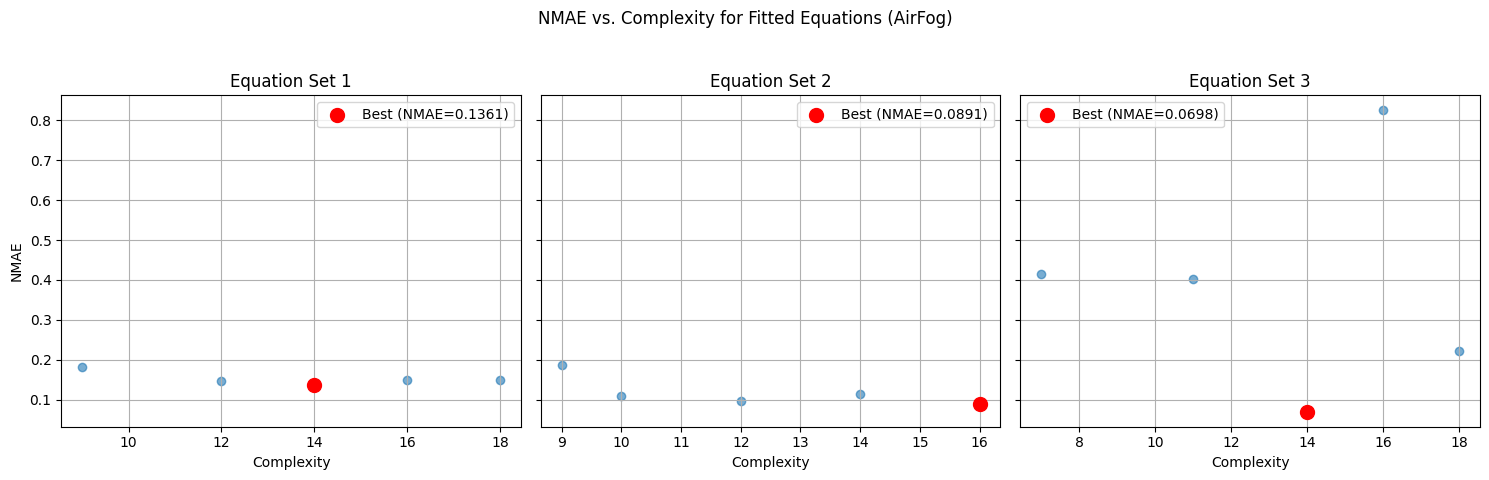

Experiment 1 finished.
Running experiment 2...
Invalid equation: min(1,max(0,x1/(1+exp(-x2*x3))). Error: '(' was never closed (<string>, line 1)
Invalid equation: min(1,max(0,x1/(1+exp(-x2*x3))). Error: '(' was never closed (<string>, line 1)


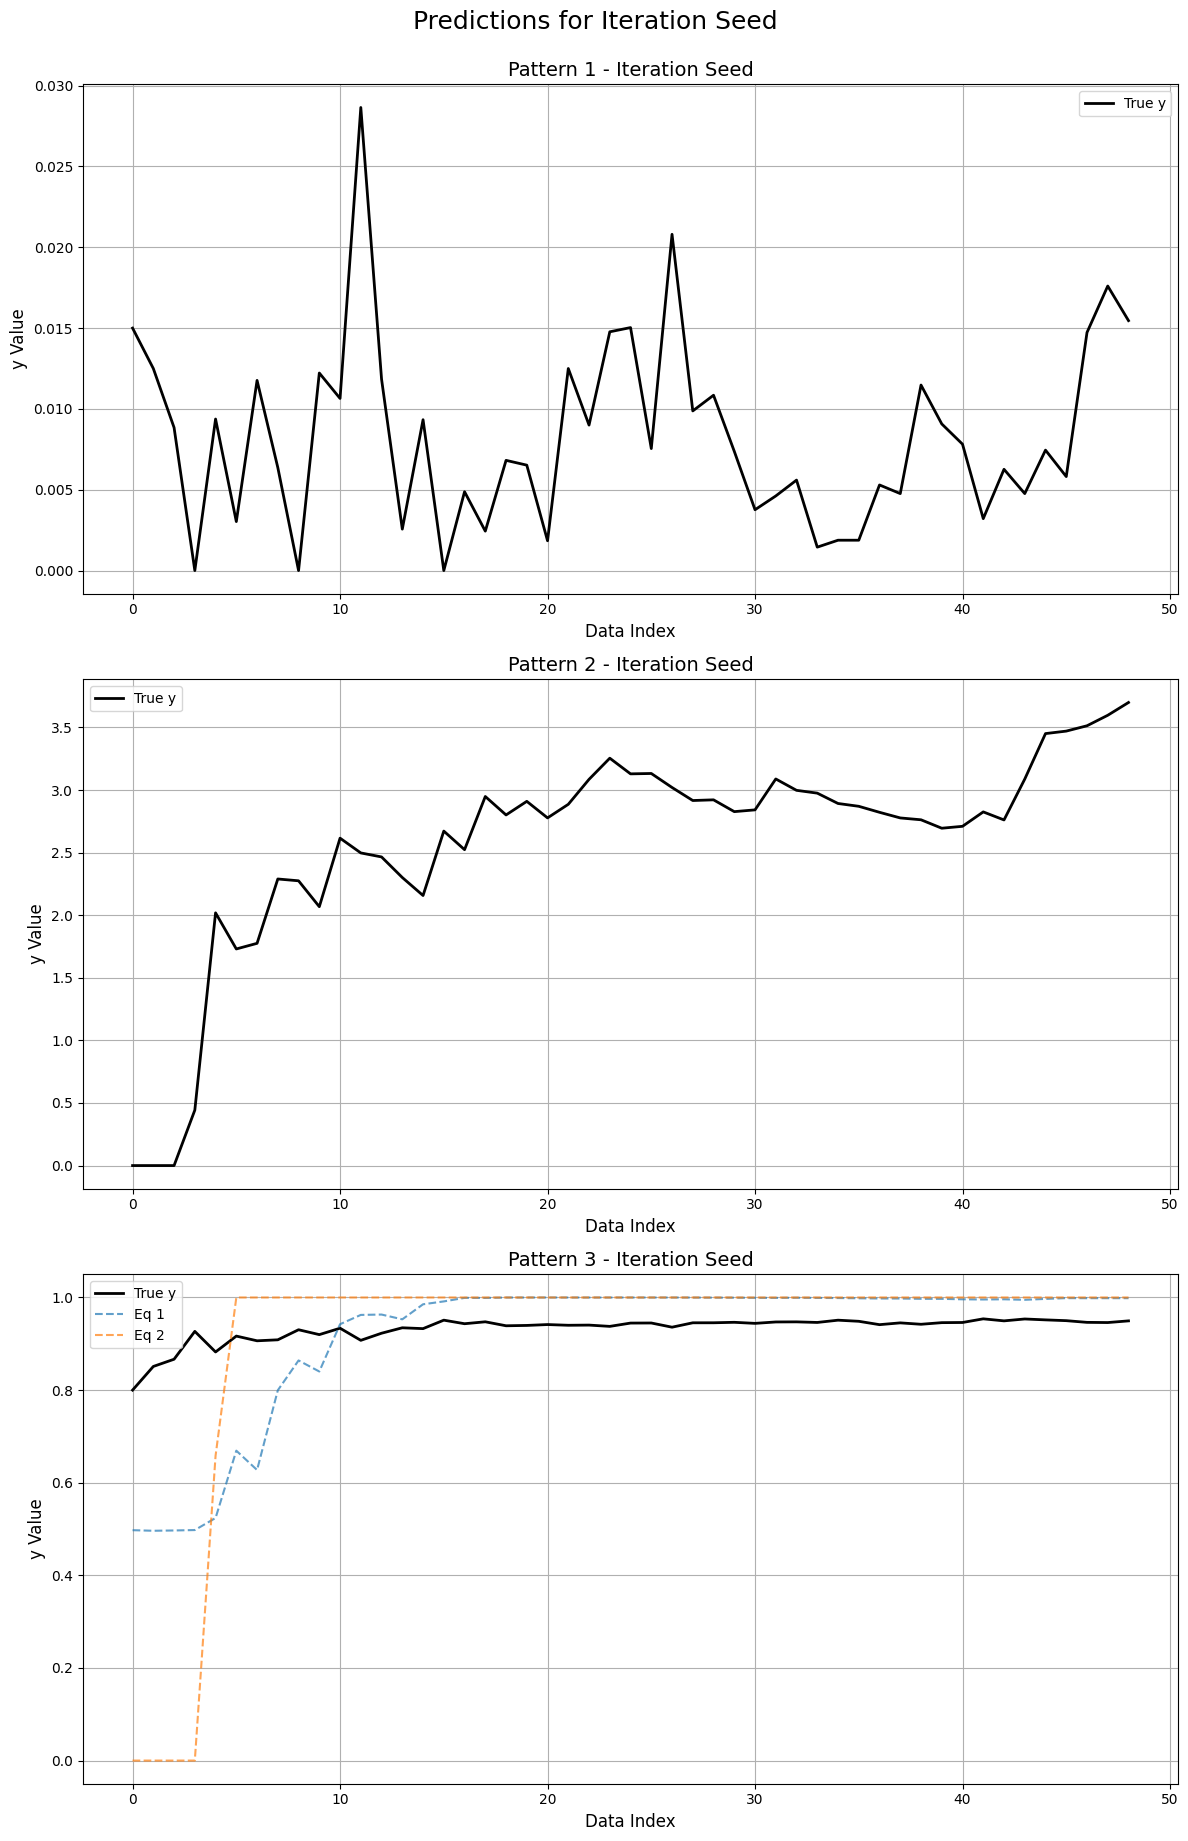

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1 Analysis:

- The dependent variable y shows oscillating behavior influenced by various factors including vehicle density, UAV density, task success ratio, and vehicle counts at key junctions.
- Polynomial terms might capture the oscillating nature; considering terms like x1^2, x2^3 may help.
- Logarithmic or exponential structures could capture multiplicative effects.
- Residual combinations like moving averages can smooth out fluctuations.

Pattern 2 Analysis:

- The dependent variable y (V2U rate) is influenced by vehicle density, UAV density, and compute load.
- The V2U rate might be proportional to vehicle density and inversely proportional to compute load, suggesting division and multiplicative terms.
- Polynomial terms could capture non-linear relationships, e.g., x1^2 or x3^3.
- Logarithmic terms could help with multiplicative effects.

Pattern 3 Analysis:

- The dependent variable y (task succes

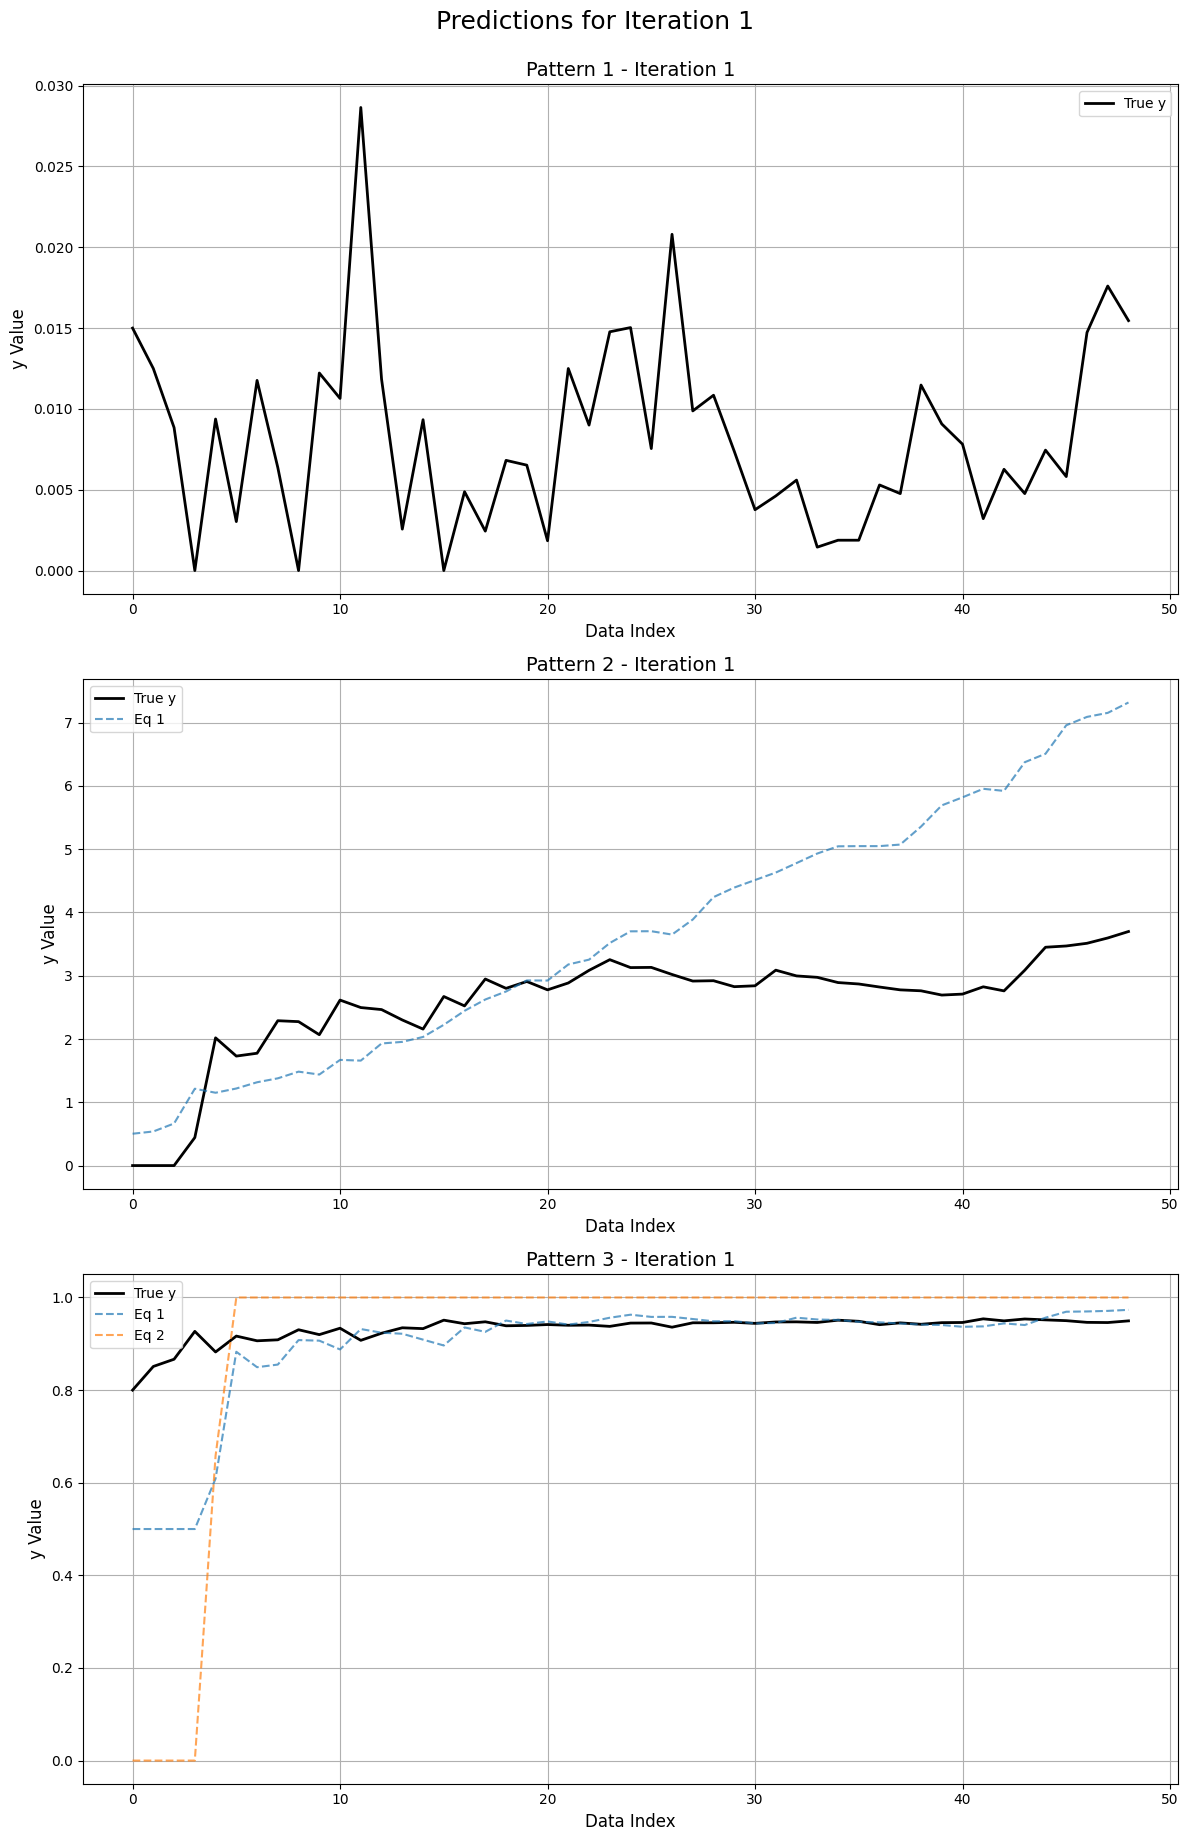

Iteration:1
SciPy feedback used for this iteration:
[[], [{'equation': 'x1+x2*log(x3+1)', 'complexity': 8, 'nmae': np.float64(0.3765376357719981), 'fitted_params': []}], [{'equation': '1/(1+exp(-x1*x2+x3))', 'complexity': 12, 'nmae': np.float64(0.605856233630304), 'fitted_params': []}, {'equation': 'min(1,max(0,x1+x2-x3**2))', 'complexity': 7, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}, {'equation': 'min(1,max(0,x1+x2-x3**2))', 'complexity': 7, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}]]
LLM thoughts:
The first pattern involves predicting the average compute load for the next time slot. Given the complexity and oscillatory nature of the compute load, and the influence of task success ratio, vehicle density, UAV density, and junction vehicle counts, potential expressions could include polynomial terms, logarithmic or exponential structures, a

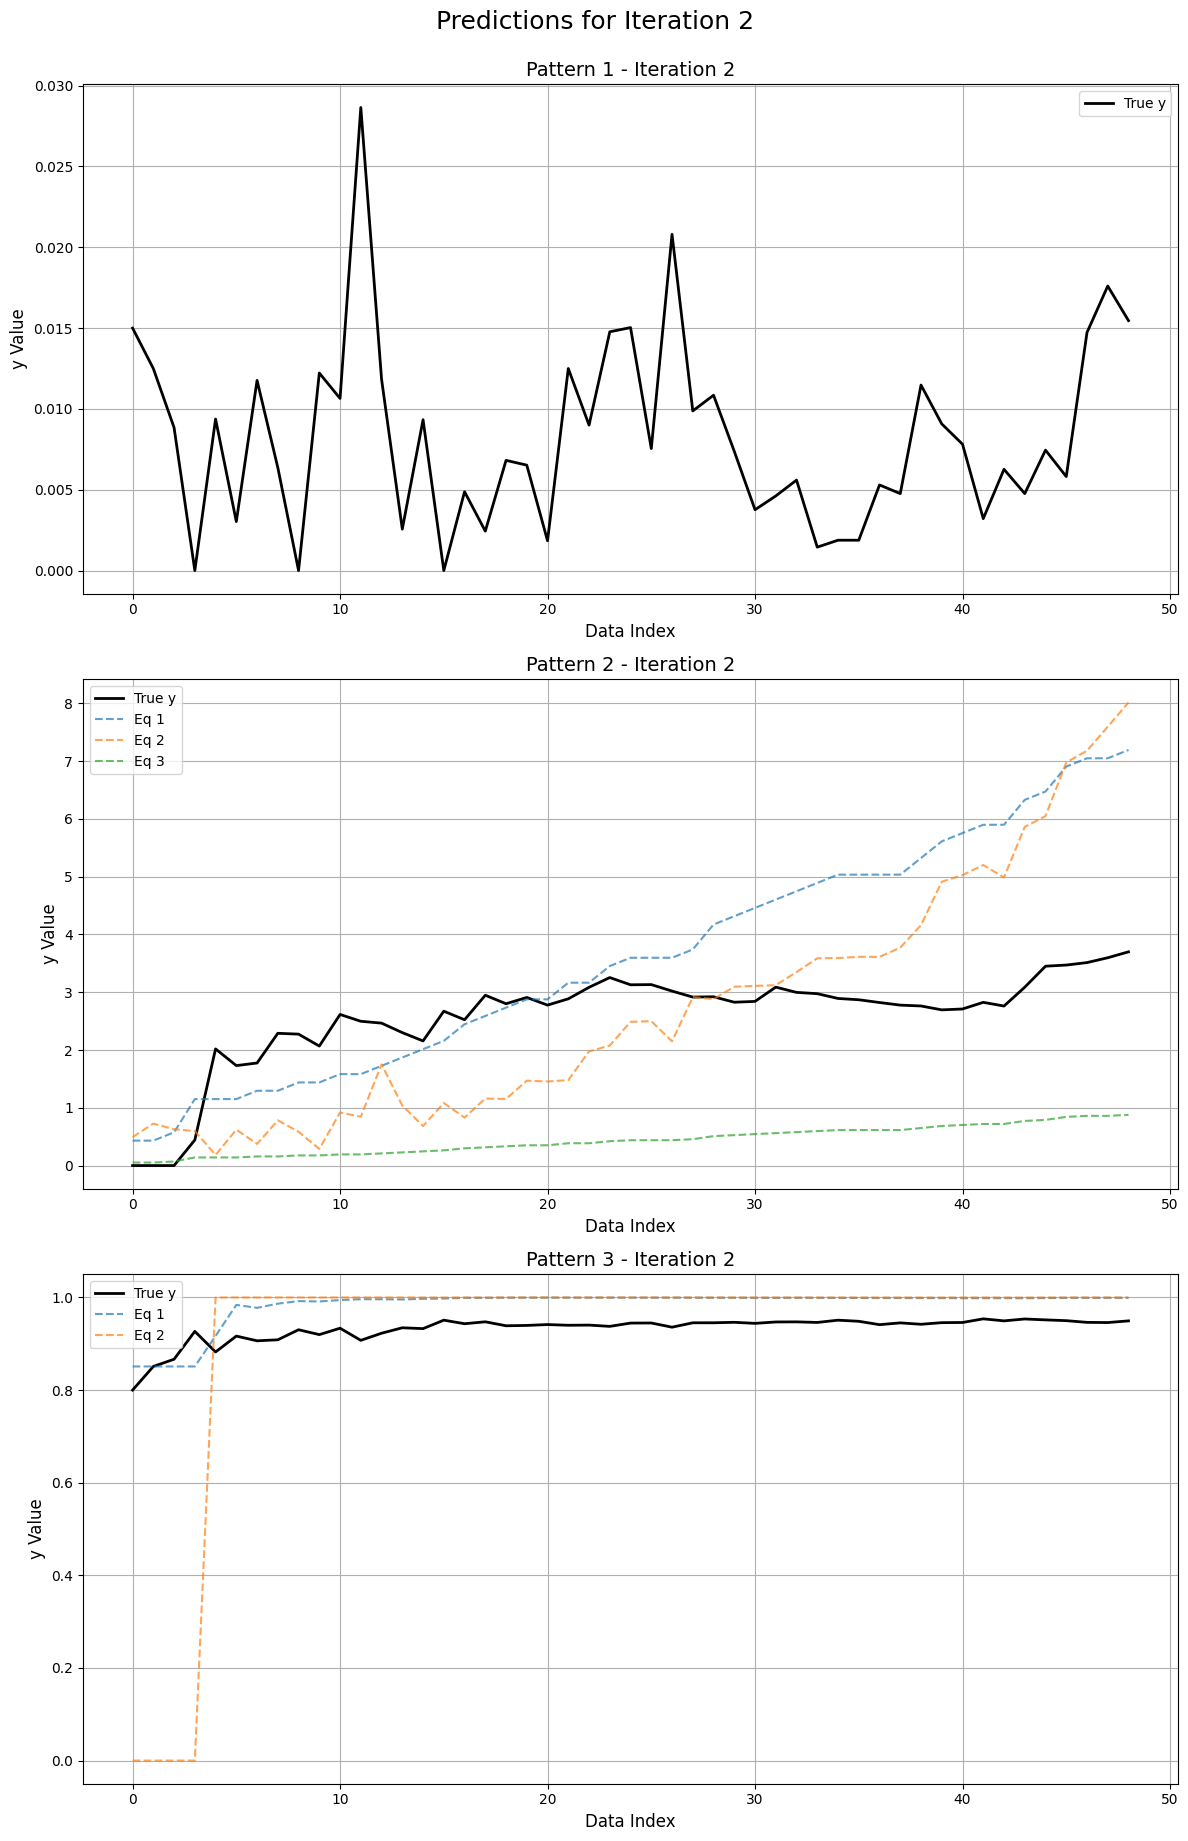

Iteration:2
SciPy feedback used for this iteration:
[[], [{'equation': 'x1+x2*log(x3+1)', 'complexity': 8, 'nmae': np.float64(0.3765376357719981), 'fitted_params': []}, {'equation': 'x1+exp(c[0]*x2)', 'complexity': 6, 'nmae': np.float64(0.37003368900495875), 'fitted_params': [-5.300000000000005]}, {'equation': 'x1**2/x2+c[0]*x3', 'complexity': 9, 'nmae': np.float64(0.3841890906386708), 'fitted_params': [46.67866288689663]}, {'equation': 'max(x1,x3)/(x2+1)', 'complexity': 5, 'nmae': np.float64(0.5801084552465903), 'fitted_params': []}], [{'equation': 'min(1,max(0,x1+x2-x3**2))', 'complexity': 7, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': 'min(1,max(0,x1*x2/x3))', 'complexity': 5, 'nmae': np.float64(0.8223810811548713), 'fitted_params': []}, {'equation': '1/(1+exp(-(x1+x2-c[0])))', 'complexity': 12, 'nmae': np.float64(0.3577319896056719), 'fitted_params': [-1.7429687500000028]}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.315319299

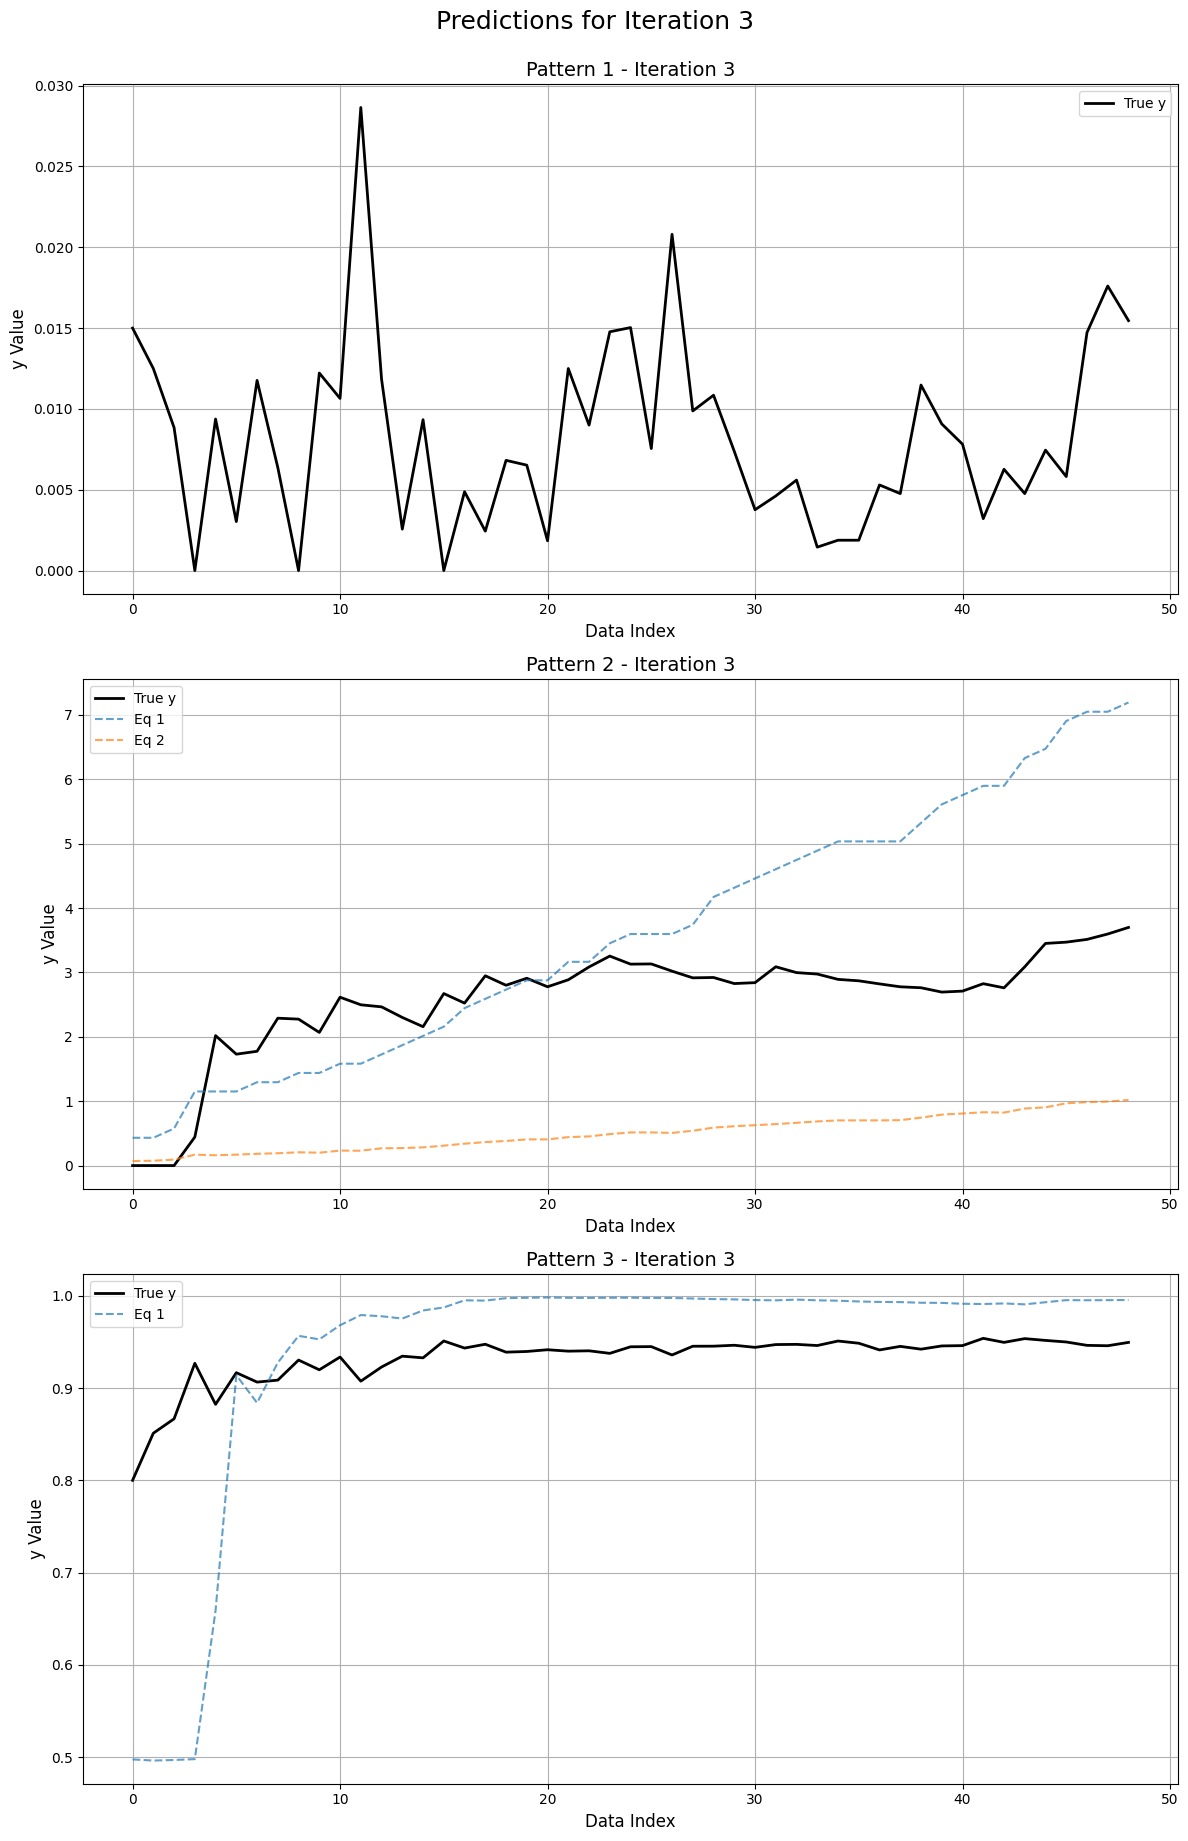

Iteration:3
SciPy feedback used for this iteration:
[[], [{'equation': 'x1/x2+x3', 'complexity': 5, 'nmae': np.float64(0.5621175816492066), 'fitted_params': []}, {'equation': 'x1**2/x2+c[0]*x3', 'complexity': 9, 'nmae': np.float64(0.3841890906386708), 'fitted_params': [46.67866288689663]}, {'equation': 'x1+x2*log(x3+1)', 'complexity': 8, 'nmae': np.float64(0.3765376357719981), 'fitted_params': []}, {'equation': 'x1+exp(c[0]*x2)', 'complexity': 6, 'nmae': np.float64(0.37003368900495875), 'fitted_params': [-5.300000000000005]}, {'equation': 'min(x1,x2,movavg(3, 5))', 'complexity': 1, 'nmae': np.float64(0.37003368900495875), 'fitted_params': []}], [{'equation': 'min(1,max(0,x1+x2-x3**2))', 'complexity': 7, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': 'min(1,max(0,x1*x2/x3))', 'complexity': 5, 'nmae': np.float64(0.8223810811548713), 'fitted_params': []}, {'equation': '1/(1+exp(-(x1+x2-c[0])))', 'complexity': 12, 'nmae': np.float64(0.3577319896056719), 'fitted_

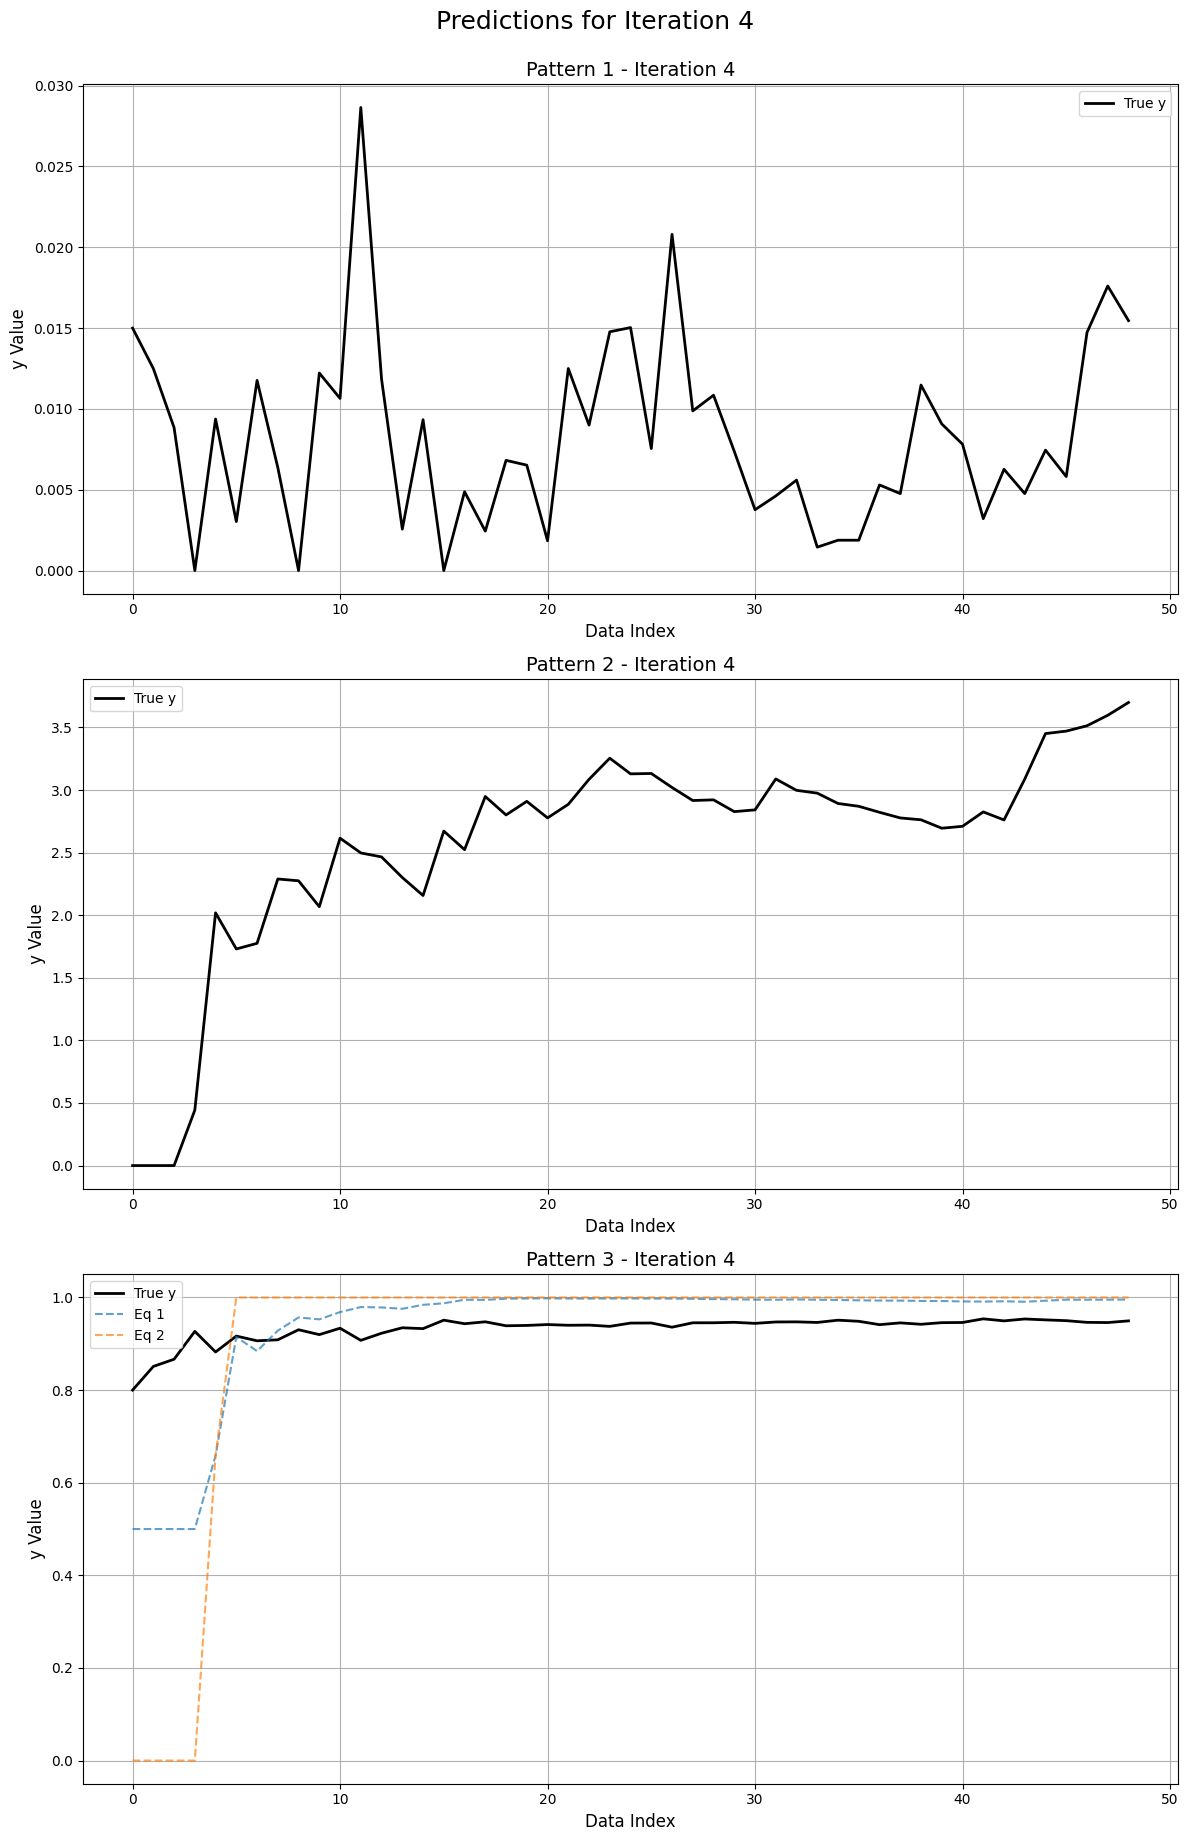

Iteration:4
SciPy feedback used for this iteration:
[[], [{'equation': 'x1/x2+x3', 'complexity': 5, 'nmae': np.float64(0.5621175816492066), 'fitted_params': []}, {'equation': 'x1**2/x2+c[0]*x3', 'complexity': 9, 'nmae': np.float64(0.3841890906386708), 'fitted_params': [46.67866288689663]}, {'equation': 'x1+x2*log(x3+1)', 'complexity': 8, 'nmae': np.float64(0.3765376357719981), 'fitted_params': []}, {'equation': 'x1+exp(c[0]*x2)', 'complexity': 6, 'nmae': np.float64(0.37003368900495875), 'fitted_params': [-5.300000000000005]}, {'equation': 'min(x1,x2,movavg(3, 5))', 'complexity': 1, 'nmae': np.float64(0.37003368900495875), 'fitted_params': []}], [{'equation': 'min(1,max(0,x1+x2-x3**2))', 'complexity': 7, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': 'min(1,max(0,x1*x2/x3))', 'complexity': 5, 'nmae': np.float64(0.8223810811548713), 'fitted_params': []}, {'equation': '1/(1+exp(-x1-x2))', 'complexity': 10, 'nmae': np.float64(0.49163277912998493), 'fitted_params

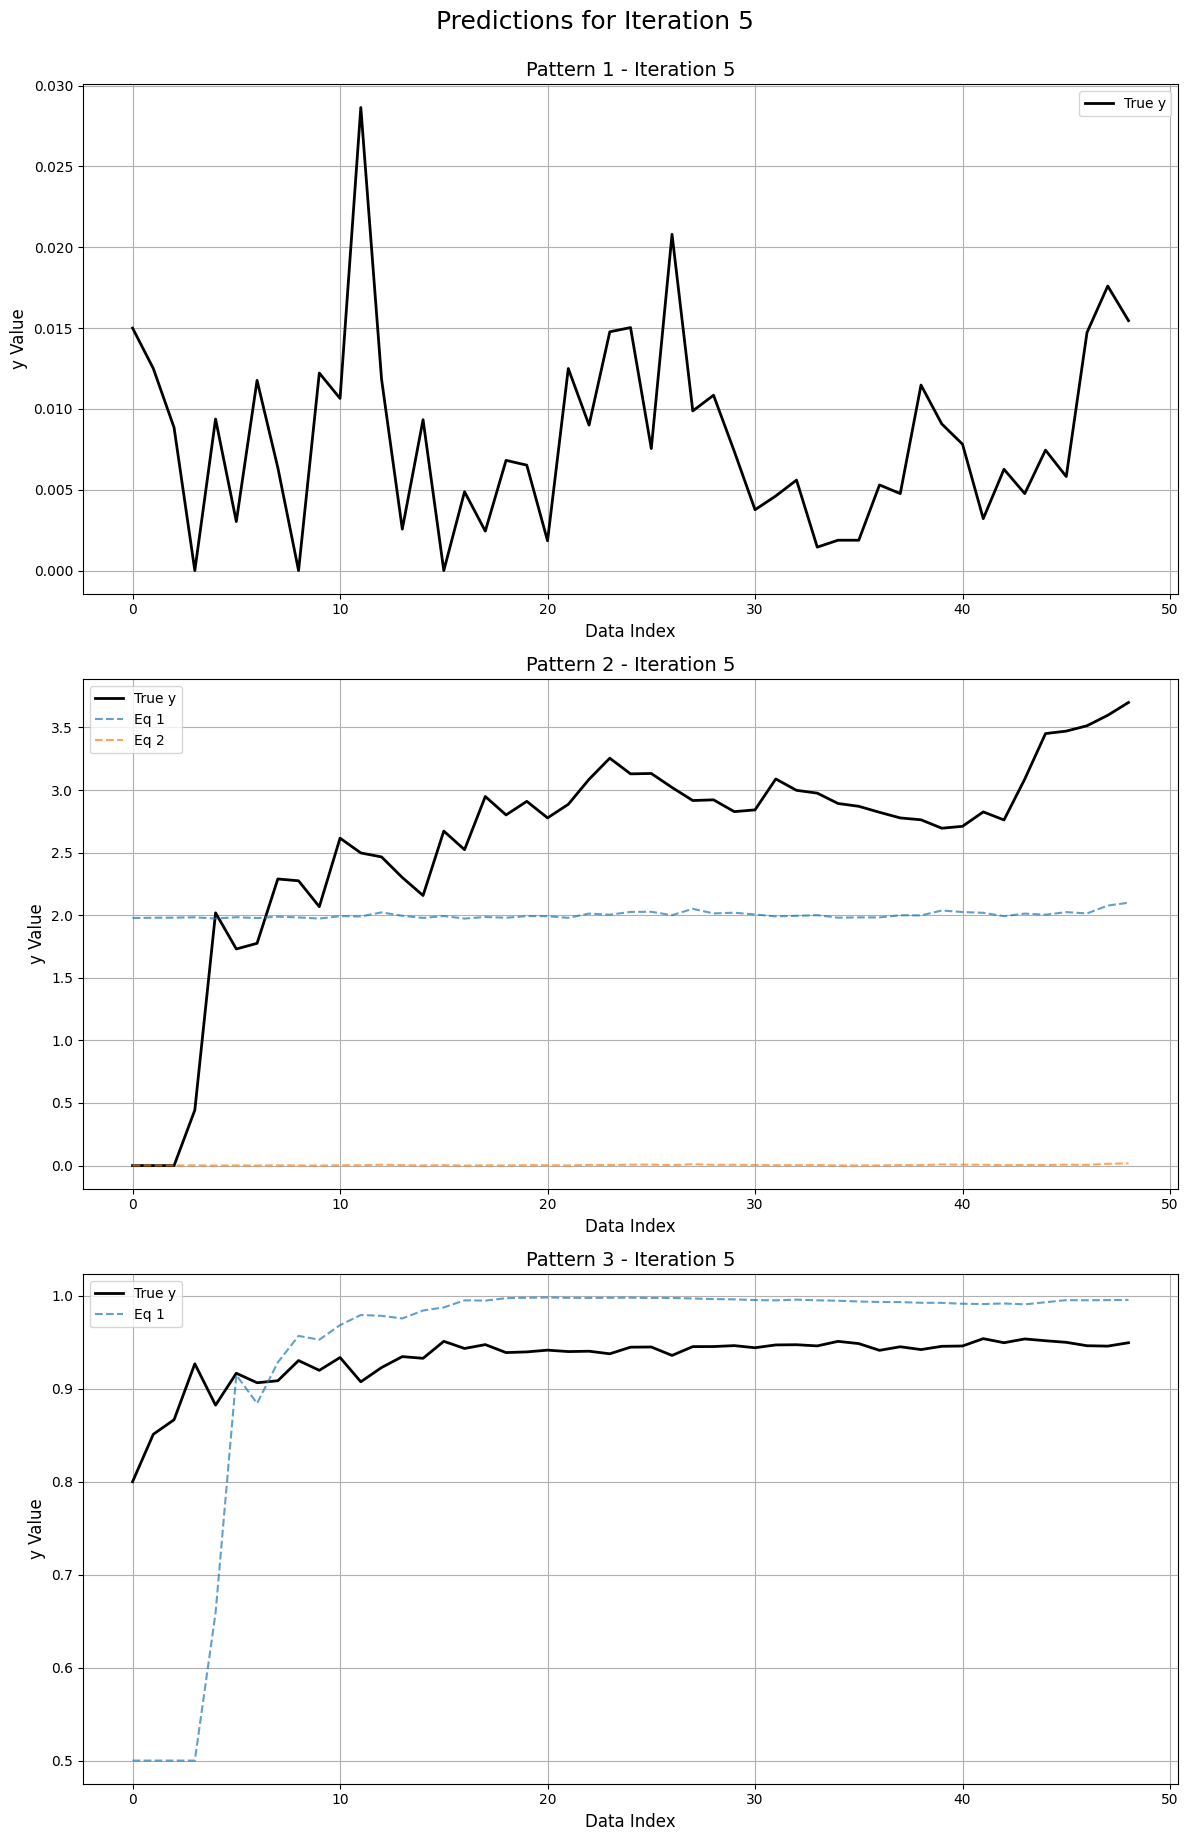

Iteration:5
SciPy feedback used for this iteration:
[[], [{'equation': 'x1/x2+x3', 'complexity': 5, 'nmae': np.float64(0.5621175816492066), 'fitted_params': []}, {'equation': 'x1**2/x2+c[0]*x3', 'complexity': 9, 'nmae': np.float64(0.3841890906386708), 'fitted_params': [46.67866288689663]}, {'equation': 'x1+x2*log(x3+1)', 'complexity': 8, 'nmae': np.float64(0.3765376357719981), 'fitted_params': []}, {'equation': 'min(x1,x2,movavg(3, 5))', 'complexity': 1, 'nmae': np.float64(0.37003368900495875), 'fitted_params': []}, {'equation': 'log(x2)+x1*x3', 'complexity': 6, 'nmae': np.float64(0.2431295862511095), 'fitted_params': []}], [{'equation': 'min(1,max(0,x1+x2-x3**2))', 'complexity': 7, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': 'min(1,max(0,x1*x2/x3))', 'complexity': 5, 'nmae': np.float64(0.8223810811548713), 'fitted_params': []}, {'equation': '1/(1+exp(-x1-x2))', 'complexity': 10, 'nmae': np.float64(0.49163277912998493), 'fitted_params': []}, {'equation': 

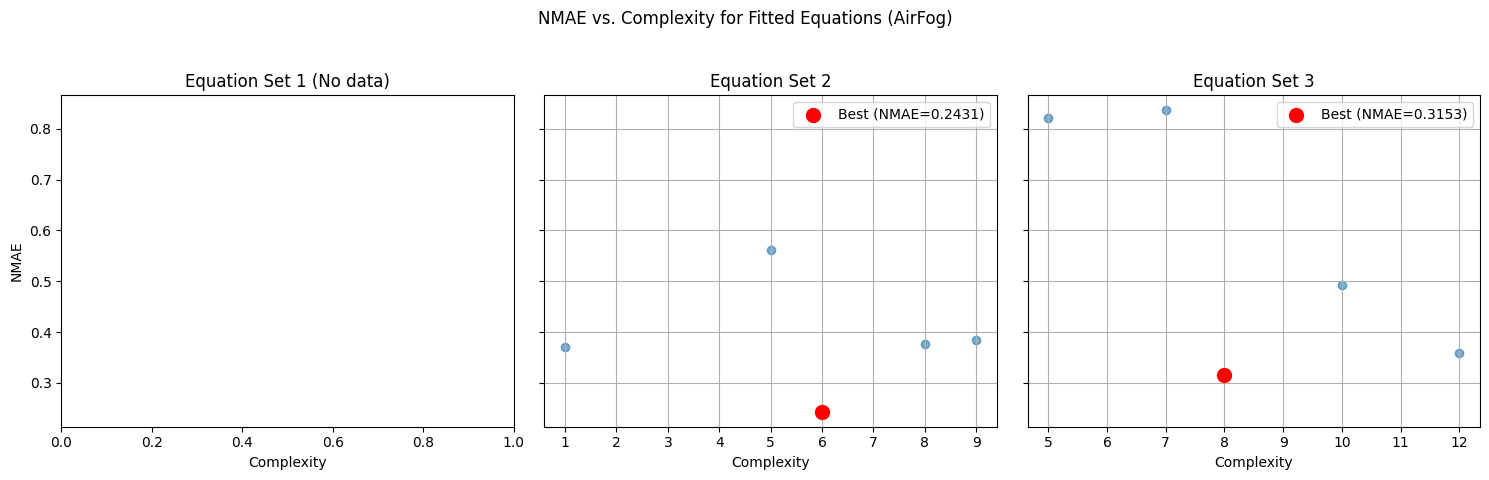

Experiment 2 finished.
Running experiment 3...
Invalid equation: x1+c[0]*x2²+c[1]*log(x3+x4+x5+x6). Error: invalid character '²' (U+00B2) (<string>, line 1)
Invalid equation: x1+c[0]*x2²+c[1]*log(x3+x4+x5+x6). Error: invalid character '²' (U+00B2) (<string>, line 1)
Invalid equation: movavg(1, 3)+c[0]*x2³+c[1]*sqrt(x5+x6). Error: invalid character '³' (U+00B3) (<string>, line 1)
Invalid equation: c[0]*x1+c[1]*x2²+x3/(x1+c[2]). Error: invalid character '²' (U+00B2) (<string>, line 1)
Invalid equation: log(x1+x2+c[0])+c[1]*x3². Error: invalid character '²' (U+00B2) (<string>, line 1)
Invalid equation: movavg(1, 5)+c[0]*x2³*x3. Error: invalid character '³' (U+00B3) (<string>, line 1)
Invalid equation: movavg(1, 3)+c[0]*x2³+c[1]*sqrt(x5+x6). Error: invalid character '³' (U+00B3) (<string>, line 1)
Invalid equation: c[0]*x1+c[1]*x2²+x3/(x1+c[2]). Error: invalid character '²' (U+00B2) (<string>, line 1)
Invalid equation: log(x1+x2+c[0])+c[1]*x3². Error: invalid character '²' (U+00B2) (<strin

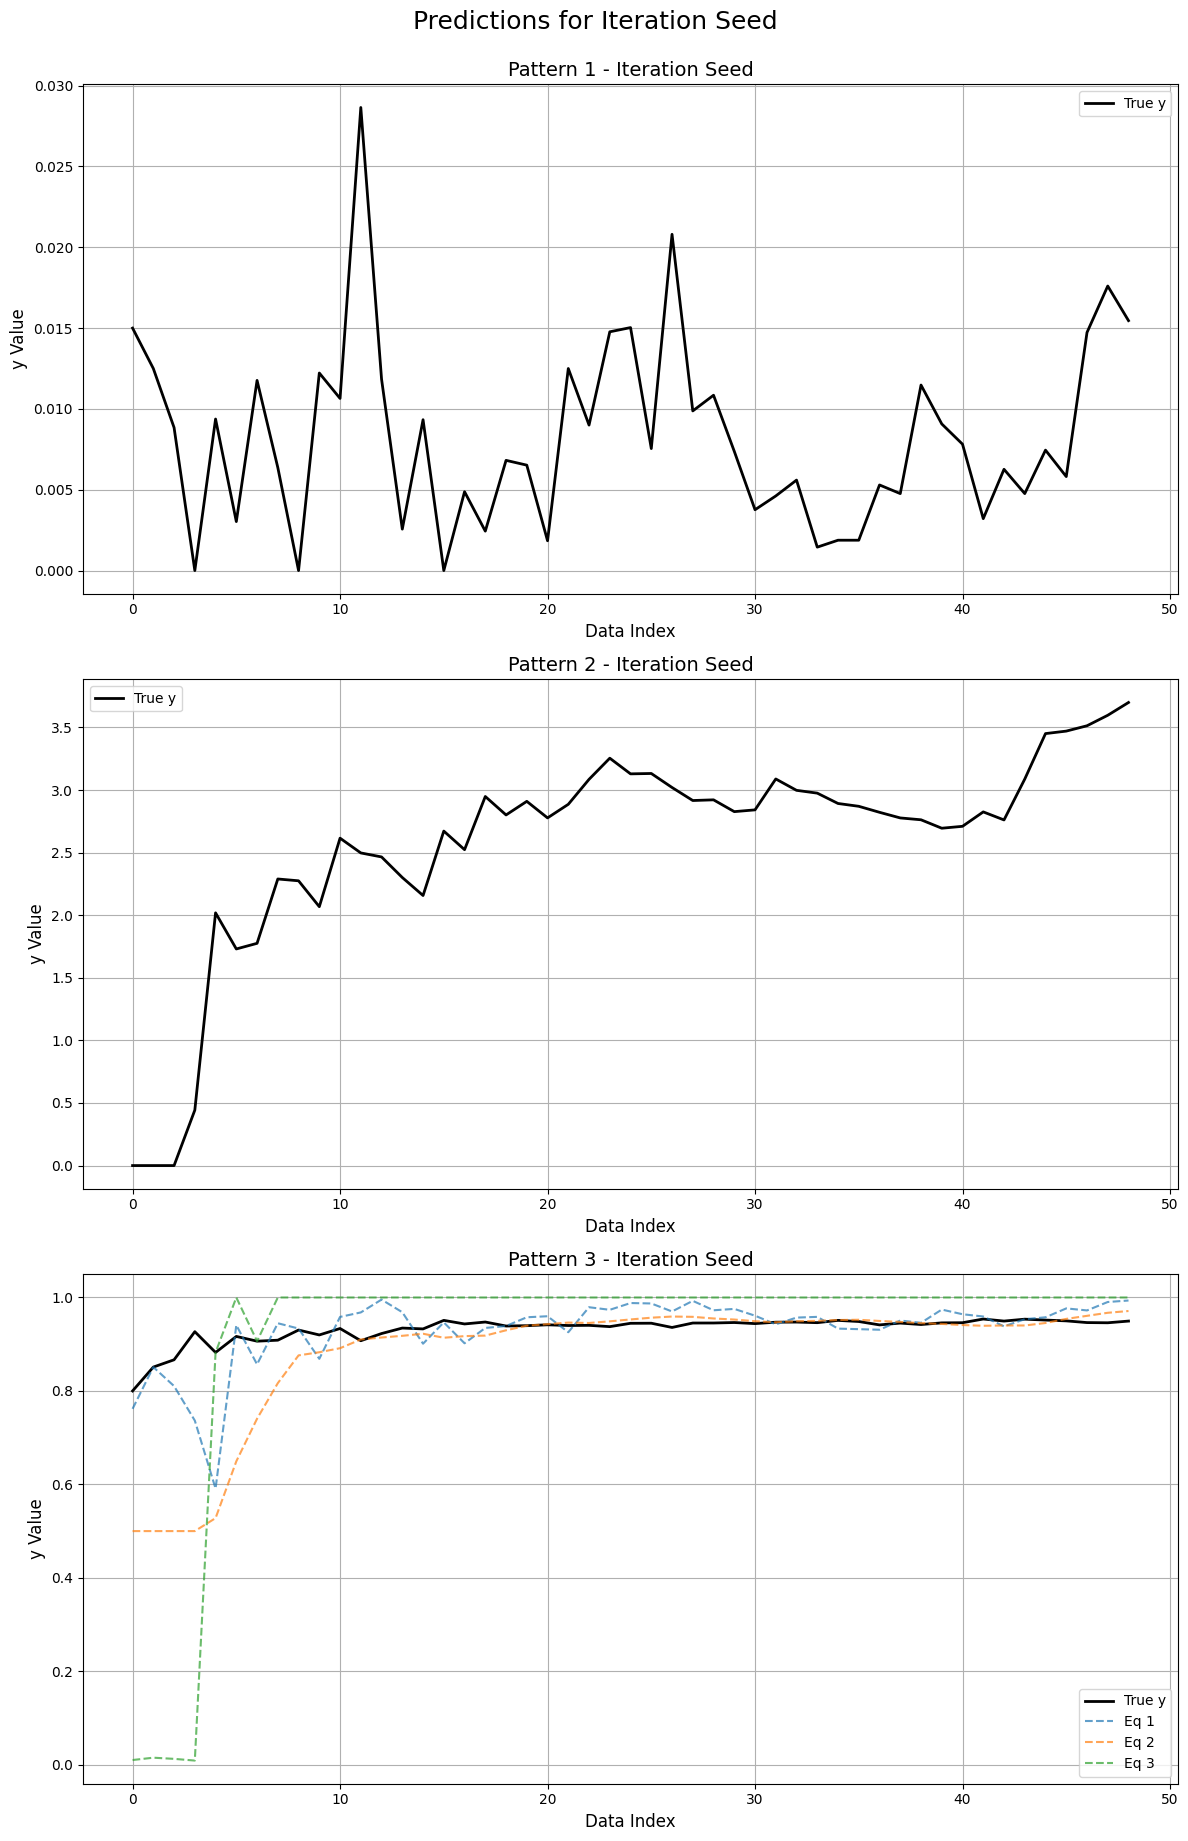

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1 Analysis:
The dependent variable, average compute load, oscillates with changes in task success ratio, vehicle density, UAV density, and junction vehicle counts. Given the non-linear nature of compute load variation, polynomial terms like x1² or x2³ are suitable to capture the variations. Logarithmic terms can handle multiplicative relationships due to density effects. Exponential terms might capture sudden load spikes due to high density or task arrivals. 

Pattern 2 Analysis:
The average V2U rate will depend heavily on vehicle density and UAV density, which are spatially constrained. The compute load affects the communication capability, making it crucial to incorporate multiplicative or polynomial relationships. Logarithmic terms can assist in capturing saturation or diminishing returns in V2U rates.

Pattern 3 Analysis:
The task success ratio is bounded between 0 and 1, making sigmoid functions or b

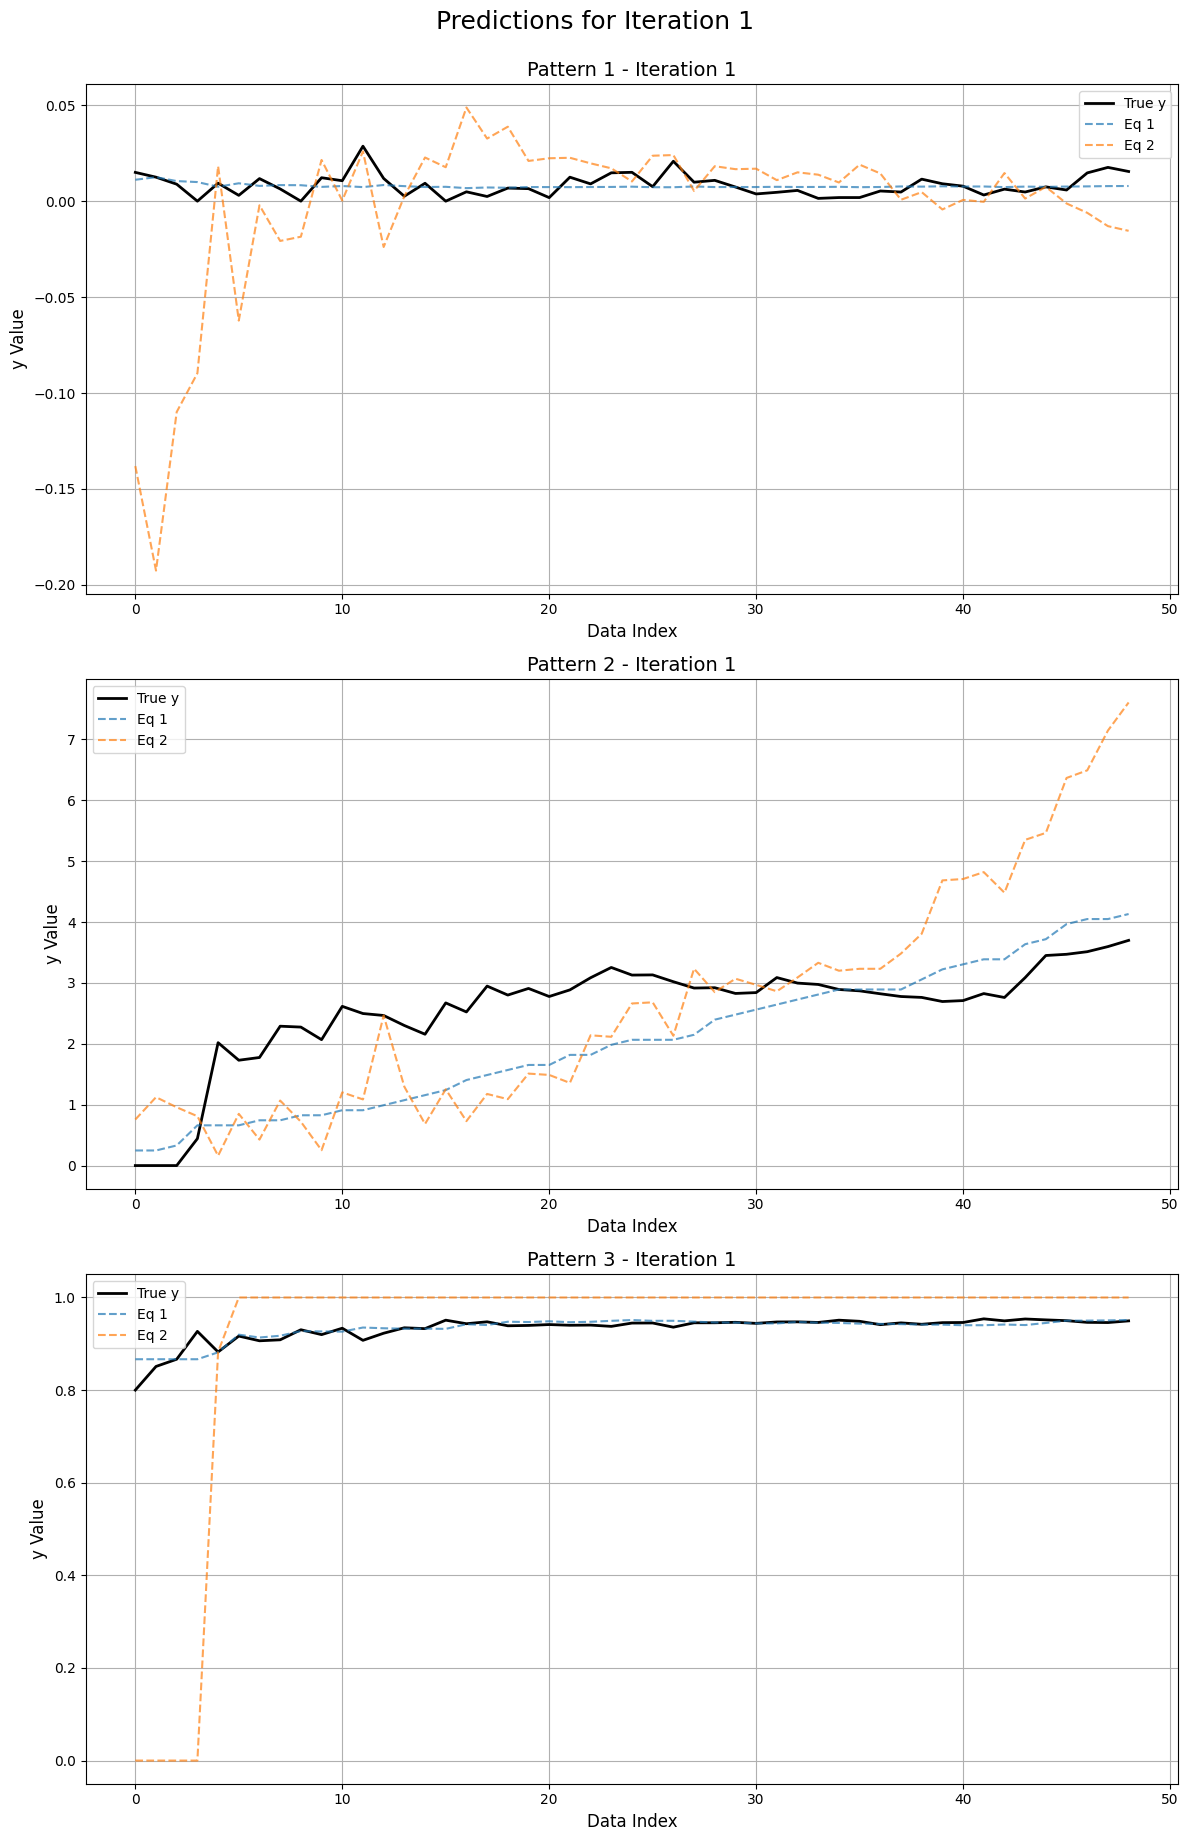

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*x2+c[2]*x3', 'complexity': 11, 'nmae': np.float64(0.14892022104021765), 'fitted_params': [-0.040270706913344834, 0.000187906655416531, 0.006204721827732702]}, {'equation': 'x1**2+c[0]*x2+c[1]', 'complexity': 9, 'nmae': np.float64(0.8621601592182382), 'fitted_params': [-0.011477327026021198, -0.8275666128671946]}], [{'equation': 'c[0]*x1*exp(-x2)', 'complexity': 8, 'nmae': np.float64(0.21184069270800746), 'fitted_params': [764.6154207951934]}, {'equation': 'x1**2/(x2+1)+c[0]*x3', 'complexity': 11, 'nmae': np.float64(0.33963101360340897), 'fitted_params': [73.36345036755203]}], [{'equation': '1/(1+exp(-(c[0]*x1+c[1]*x3)))', 'complexity': 14, 'nmae': np.float64(0.22271844616023442), 'fitted_params': [0.8306254355444316, 116.19795257358967]}, {'equation': '1/(1+exp(-(movavg(1, 4)+c[0]*x2)))', 'complexity': 12, 'nmae': np.float64(0.3760679728964281), 'fitted_params': [0.002731826654114541]}, {'equation': 'min(1

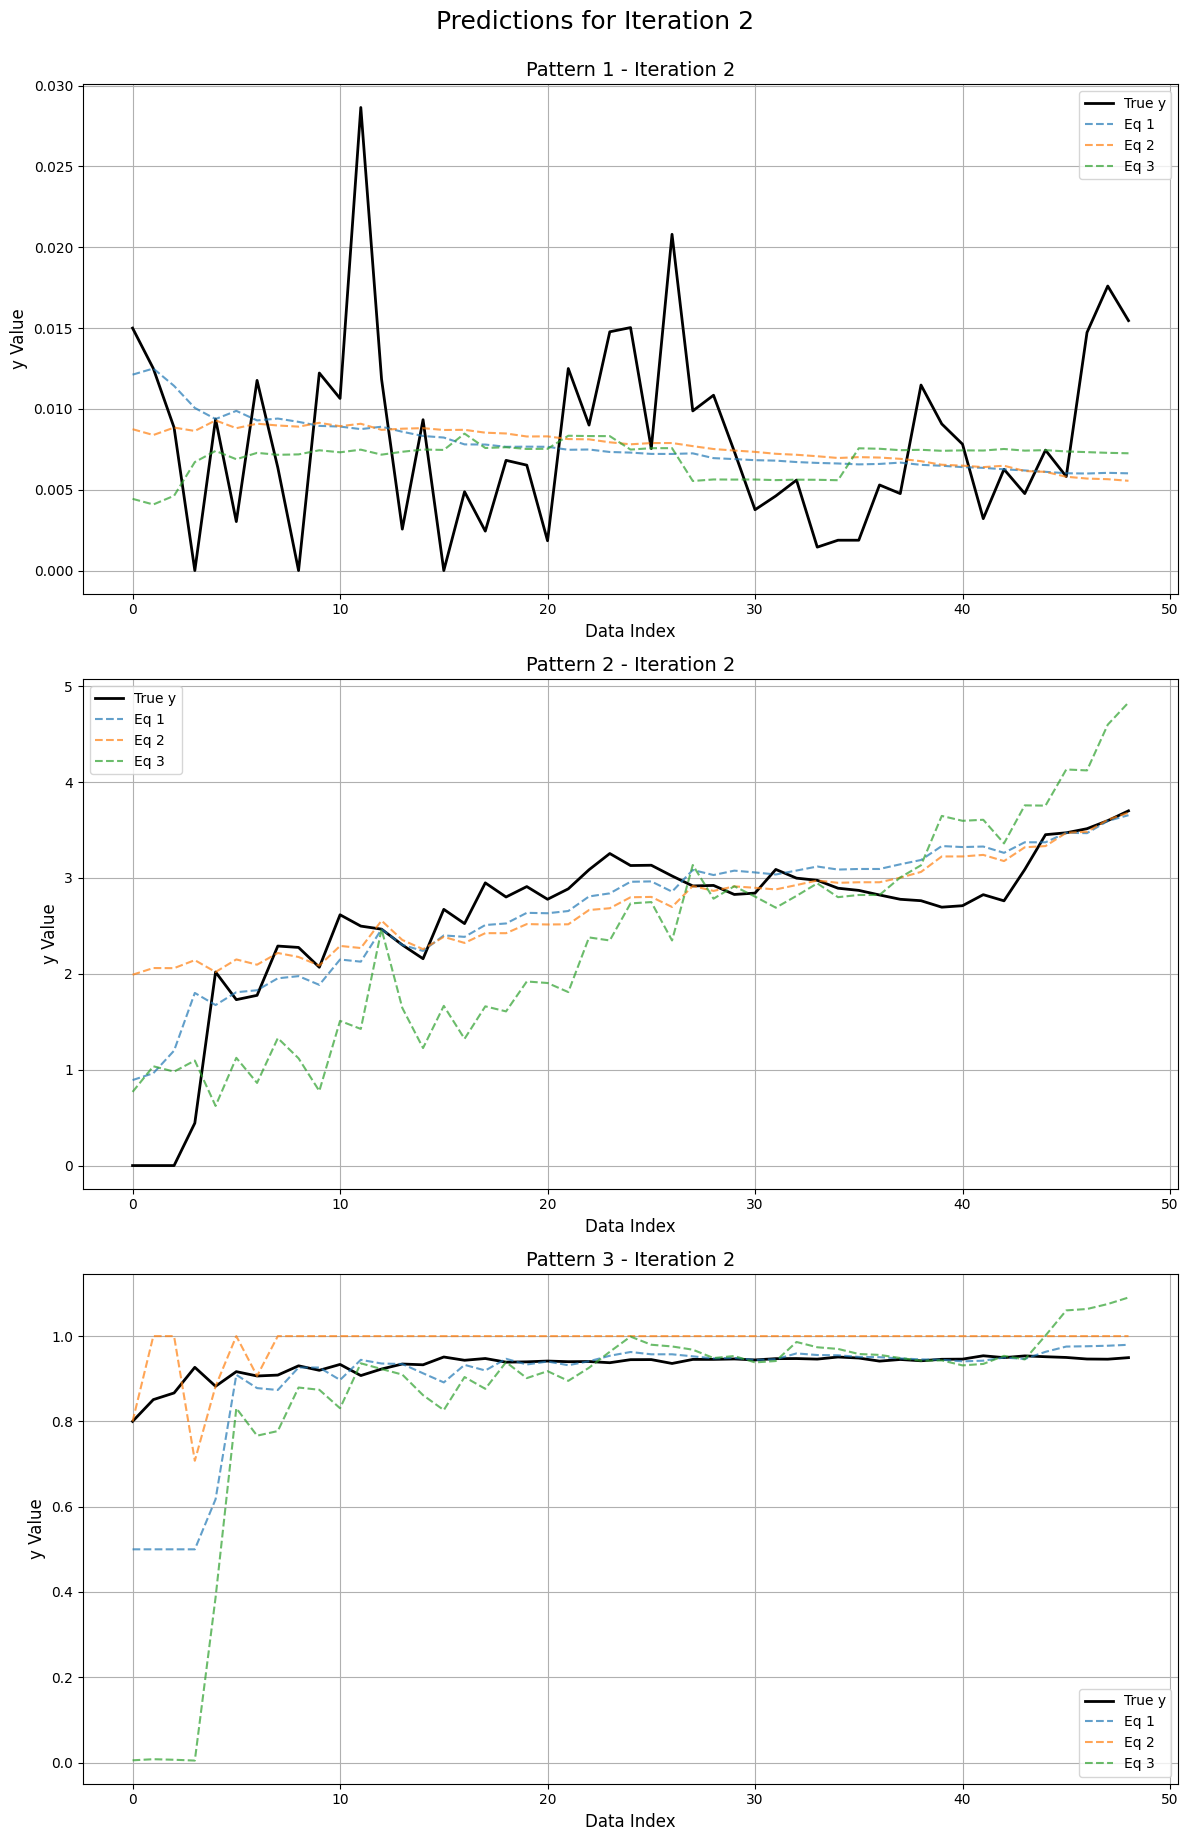

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*x2+c[2]*x3', 'complexity': 11, 'nmae': np.float64(0.14892022104021765), 'fitted_params': [-0.040270706913344834, 0.000187906655416531, 0.006204721827732702]}, {'equation': 'x1**2+c[0]*x2+c[1]', 'complexity': 9, 'nmae': np.float64(0.8621601592182382), 'fitted_params': [-0.011477327026021198, -0.8275666128671946]}, {'equation': 'c[0]*x1+c[1]*log(x2)+c[2]*movavg(3, 2)', 'complexity': 12, 'nmae': np.float64(0.1481116272055936), 'fitted_params': [-0.011386875231016946, -0.0017142701817875815, 0.0028036859508881887]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.15172267297660466), 'fitted_params': [0.010833558875807123, -9.068738546507446e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.15593438730241008), 'fitted_params': [0.006388429472967812, -1.0079058906858774e-06, 0.0019156972169657861]}], [{'equation': 'c[0]*x1*exp(-x2)', 'compl

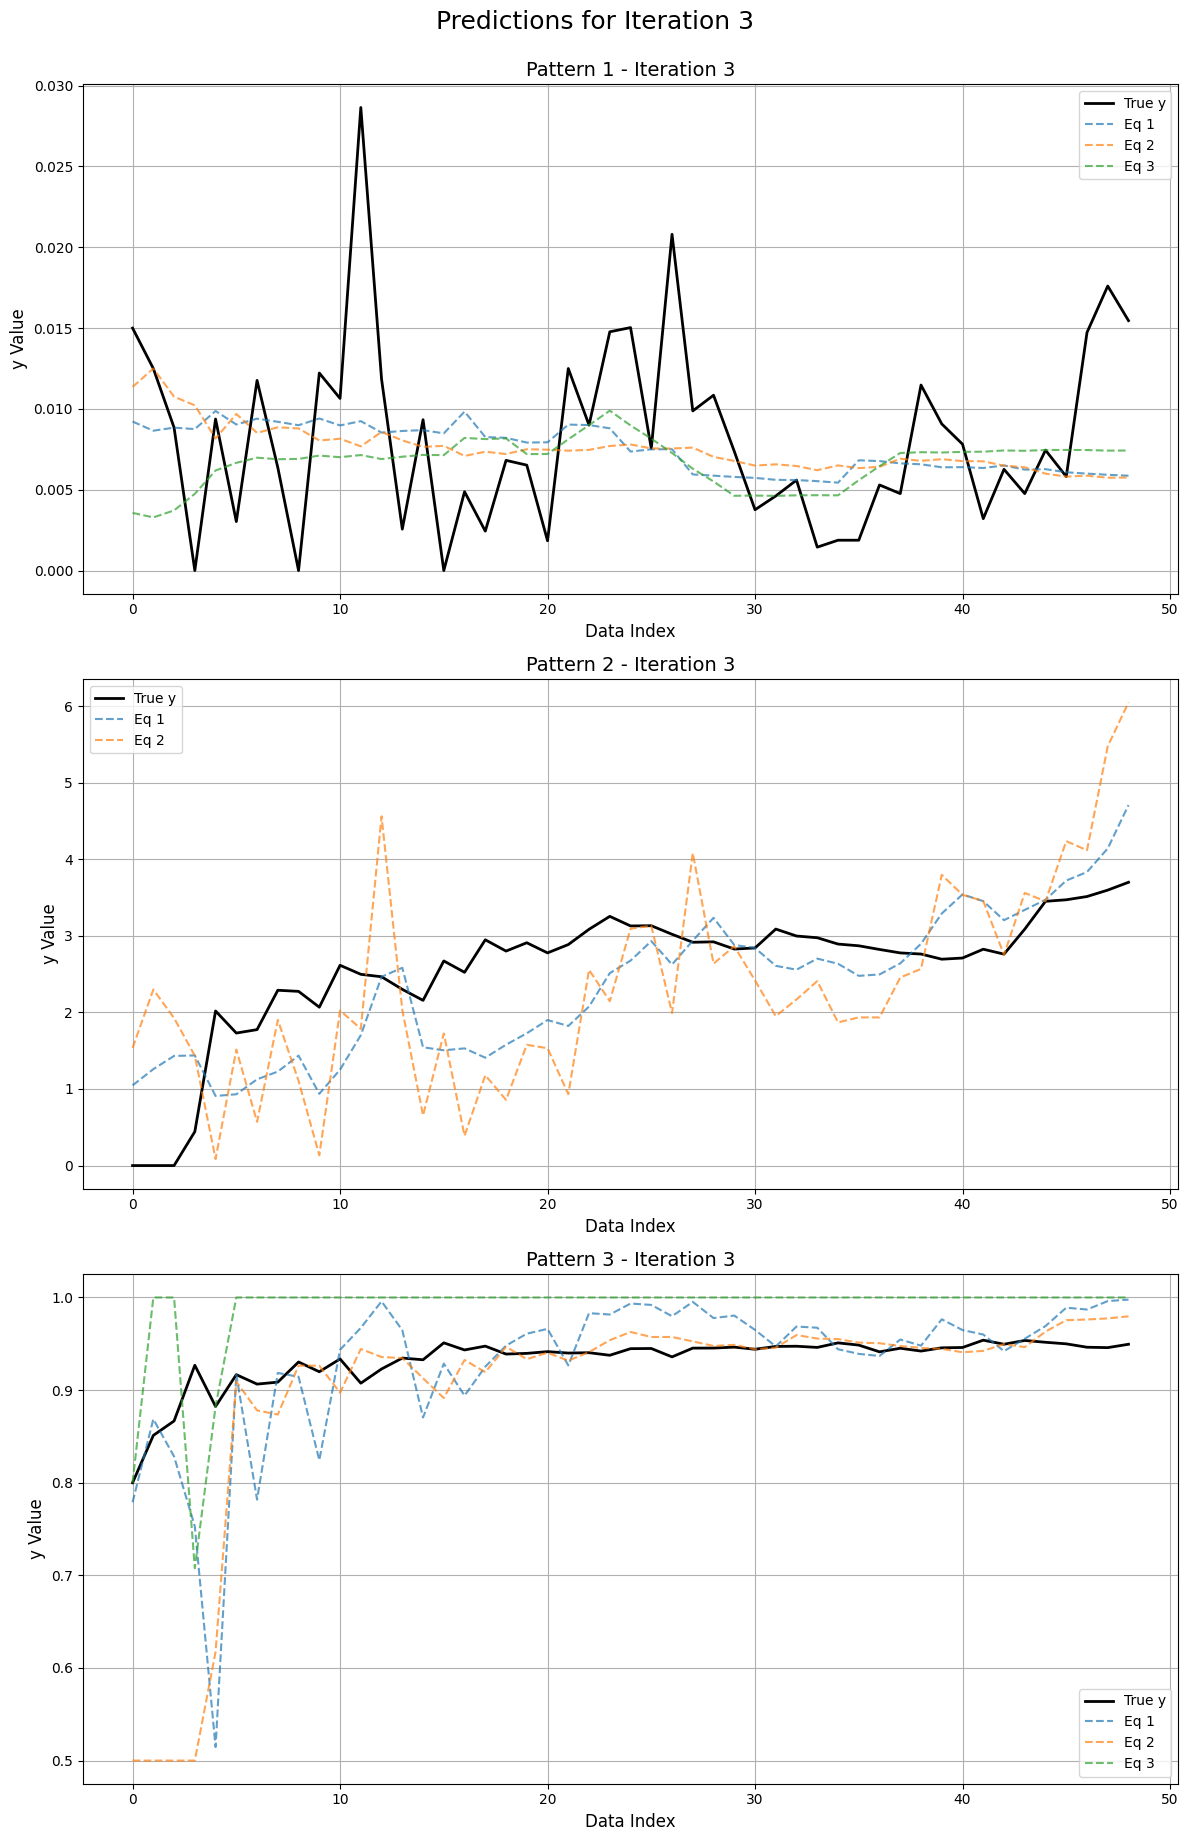

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.15593438730241008), 'fitted_params': [0.006388429472967812, -1.0079058906858774e-06, 0.0019156972169657861]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.15172267297660466), 'fitted_params': [0.010833558875807123, -9.068738546507446e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*movavg(4, 3)', 'complexity': 15, 'nmae': np.float64(0.15157355870765474), 'fitted_params': [0.005137013728756714, 4.414389841269108e-07, 0.0026660419960631114]}, {'equation': 'c[0]*x1+c[1]*x2+c[2]*x3', 'complexity': 11, 'nmae': np.float64(0.14892022104021765), 'fitted_params': [-0.040270706913344834, 0.000187906655416531, 0.006204721827732702]}, {'equation': 'c[0]*x1+c[1]*exp(x3)+c[2]*x5', 'complexity': 12, 'nmae': np.float64(0.14733003355101829), 'fitted_params': [-0.034145017829537216, 2.9911181131382143e-05, -0.0002514872999263921]}, {'

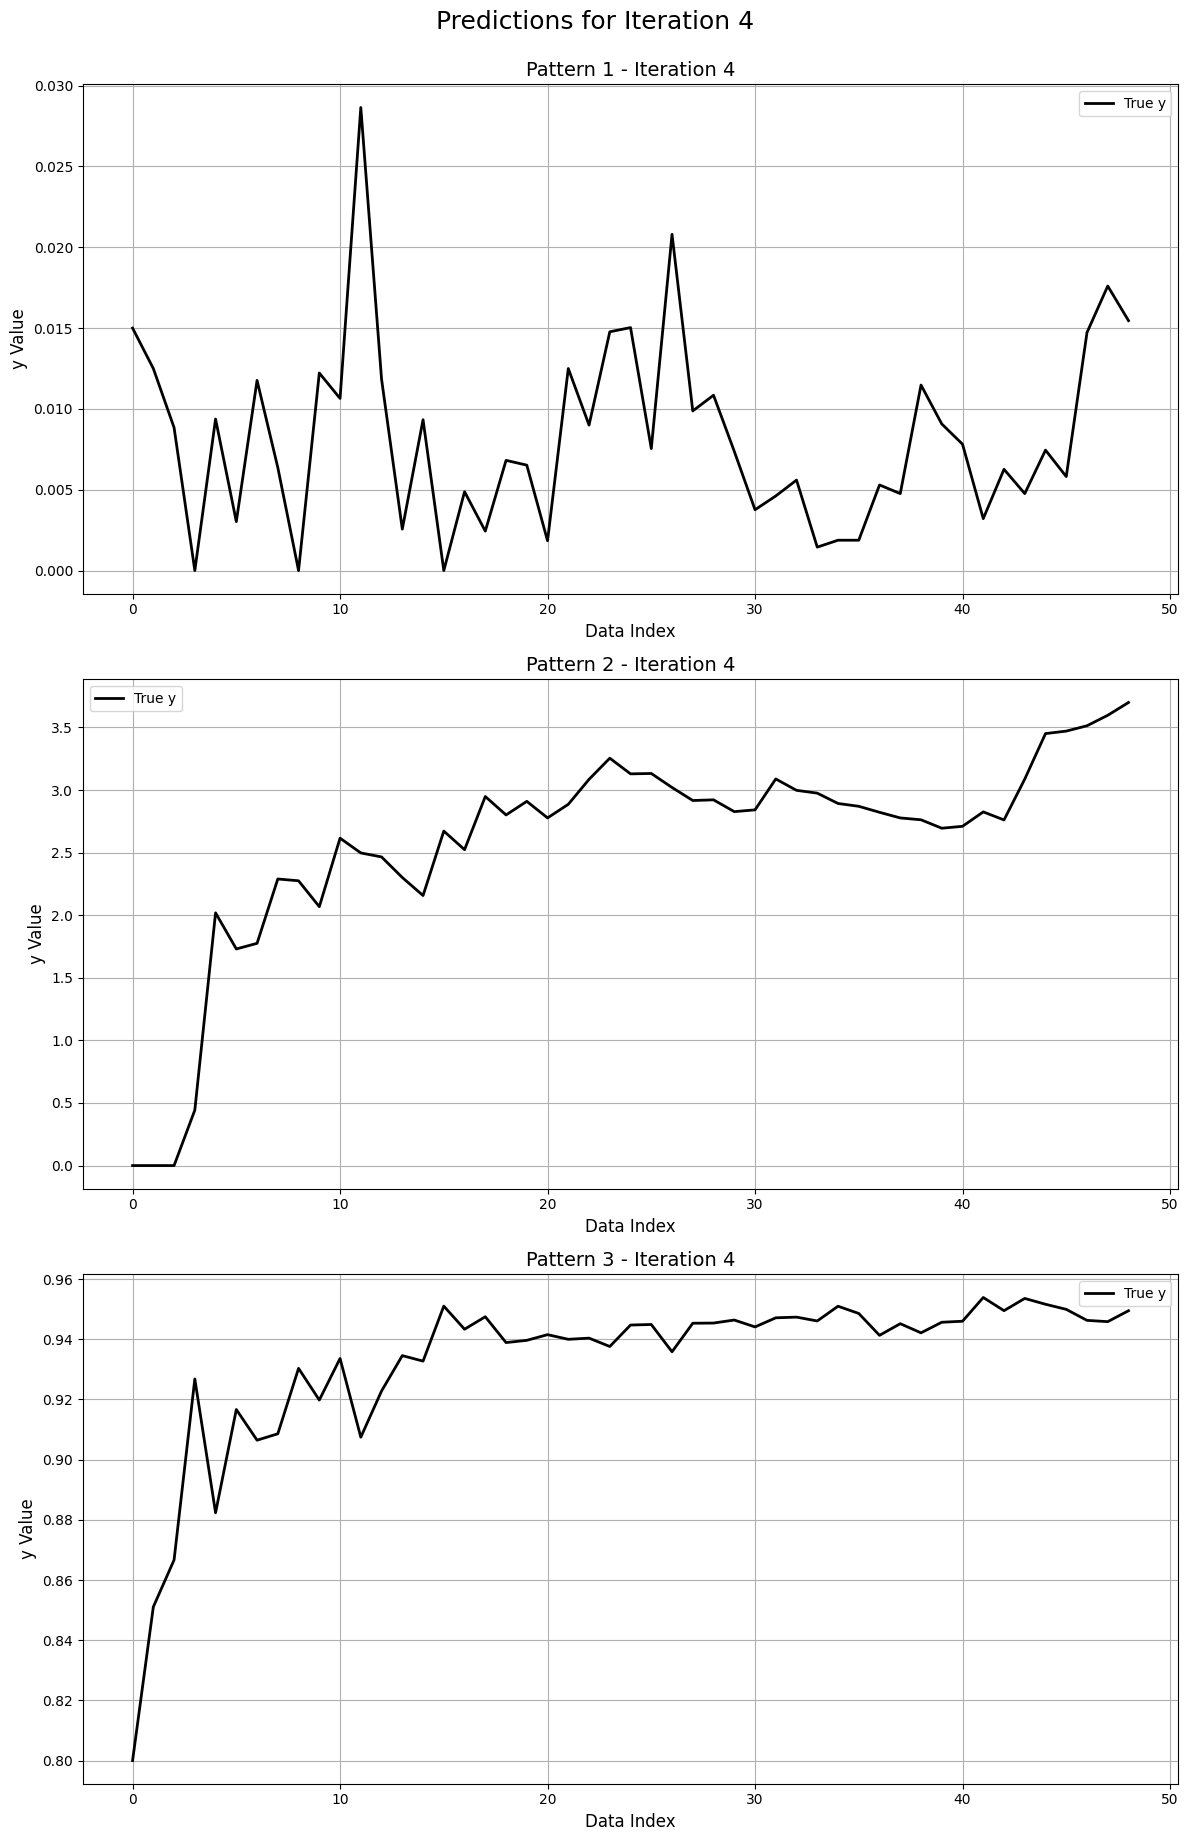

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.15593438730241008), 'fitted_params': [0.006388429472967812, -1.0079058906858774e-06, 0.0019156972169657861]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.15172267297660466), 'fitted_params': [0.010833558875807123, -9.068738546507446e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*movavg(4, 3)', 'complexity': 15, 'nmae': np.float64(0.15157355870765474), 'fitted_params': [0.005137013728756714, 4.414389841269108e-07, 0.0026660419960631114]}, {'equation': 'c[0]*x1+c[1]*x2+c[2]*x3', 'complexity': 11, 'nmae': np.float64(0.14892022104021765), 'fitted_params': [-0.040270706913344834, 0.000187906655416531, 0.006204721827732702]}, {'equation': 'c[0]*x1+c[1]*exp(x3)+c[2]*x5', 'complexity': 12, 'nmae': np.float64(0.14733003355101829), 'fitted_params': [-0.034145017829537216, 2.9911181131382143e-05, -0.0002514872999263921]}, {'

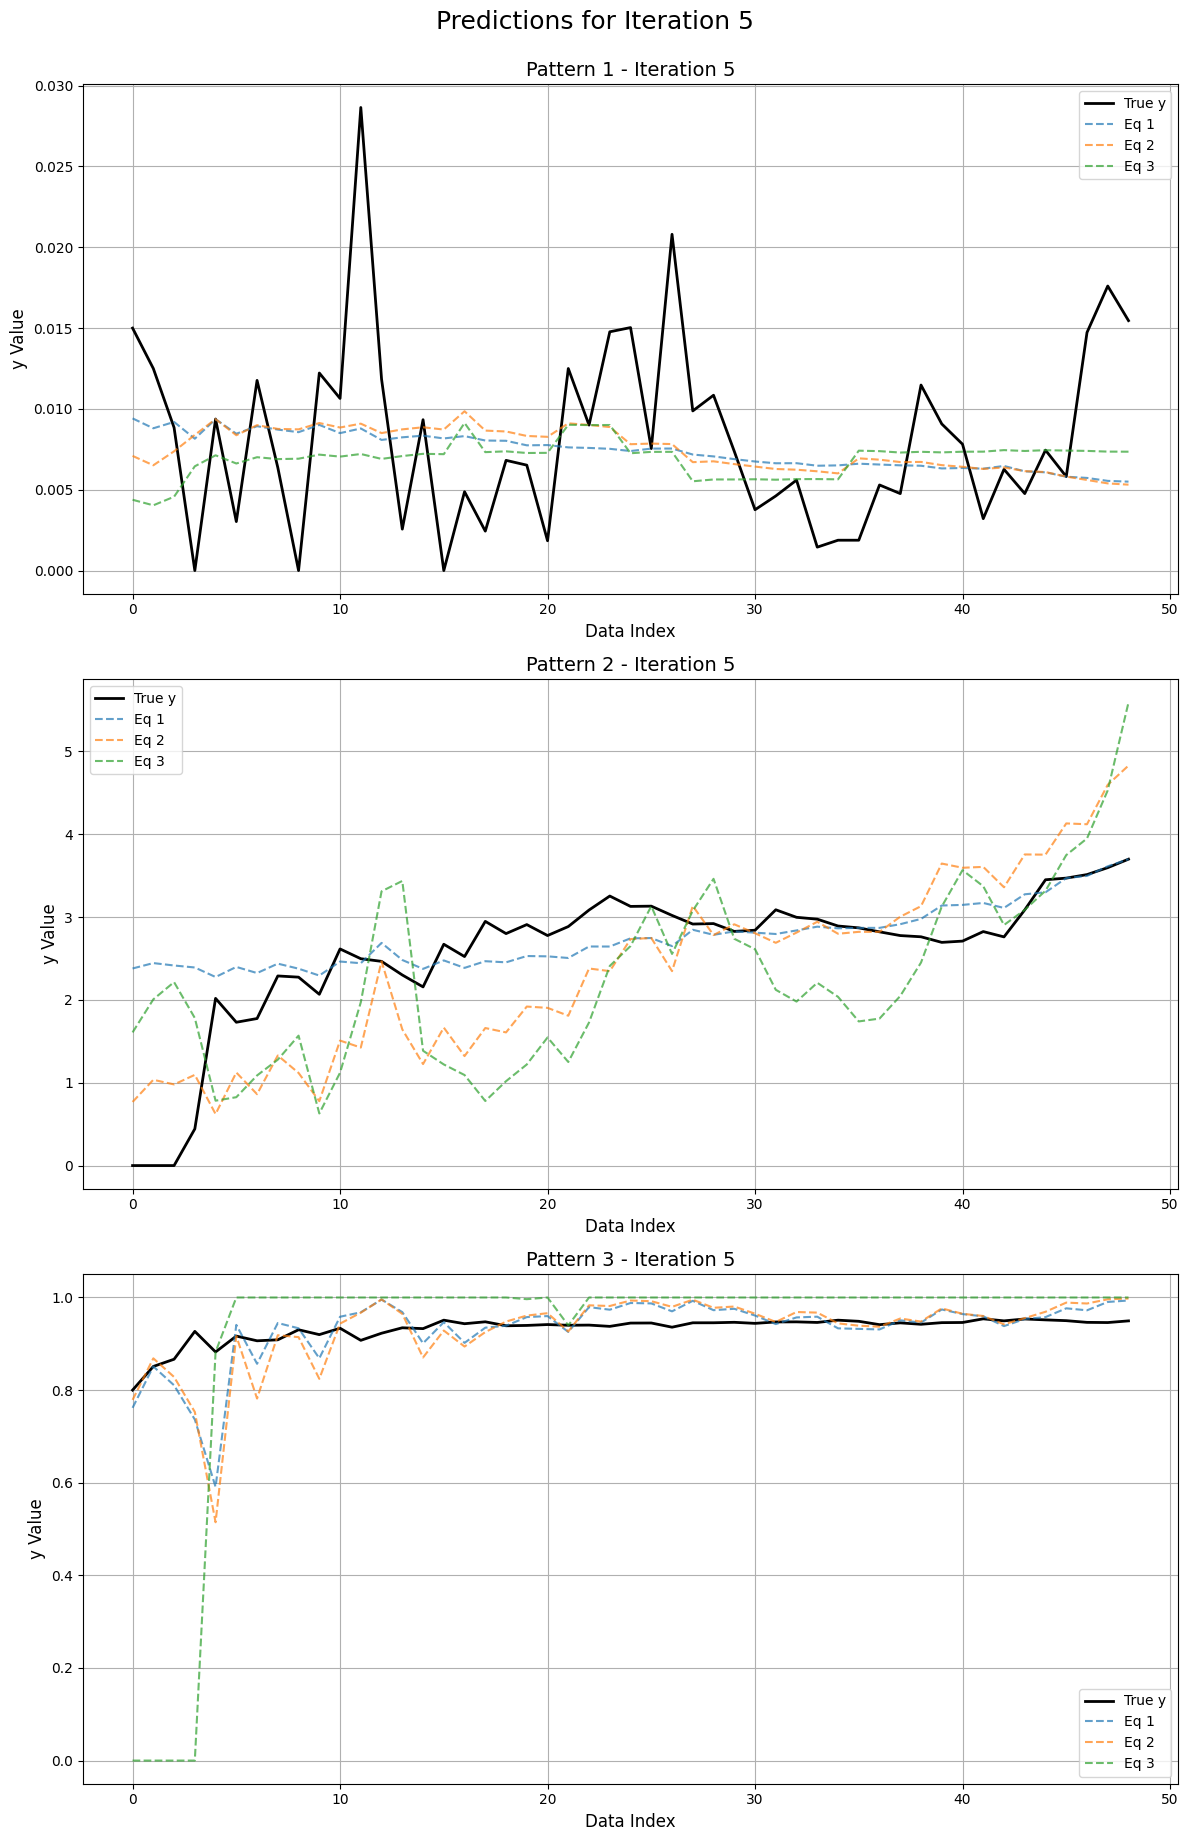

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*sqrt(x4)', 'complexity': 16, 'nmae': np.float64(0.15593438730241008), 'fitted_params': [0.006388429472967812, -1.0079058906858774e-06, 0.0019156972169657861]}, {'equation': 'c[0]*x1**2+c[1]*movavg(2, 3)+c[2]*x4', 'complexity': 13, 'nmae': np.float64(0.15224626865745164), 'fitted_params': [0.01066380962884101, -0.0007223520532589772, 0.0009017531677901894]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.15172267297660466), 'fitted_params': [0.010833558875807123, -9.068738546507446e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*movavg(4, 3)', 'complexity': 15, 'nmae': np.float64(0.15157355870765474), 'fitted_params': [0.005137013728756714, 4.414389841269108e-07, 0.0026660419960631114]}, {'equation': 'c[0]*x1+c[1]*x2+c[2]*x3', 'complexity': 11, 'nmae': np.float64(0.14892022104021765), 'fitted_params': [-0.040270706913344834, 0.000187906655416531, 0.006204721827732702]

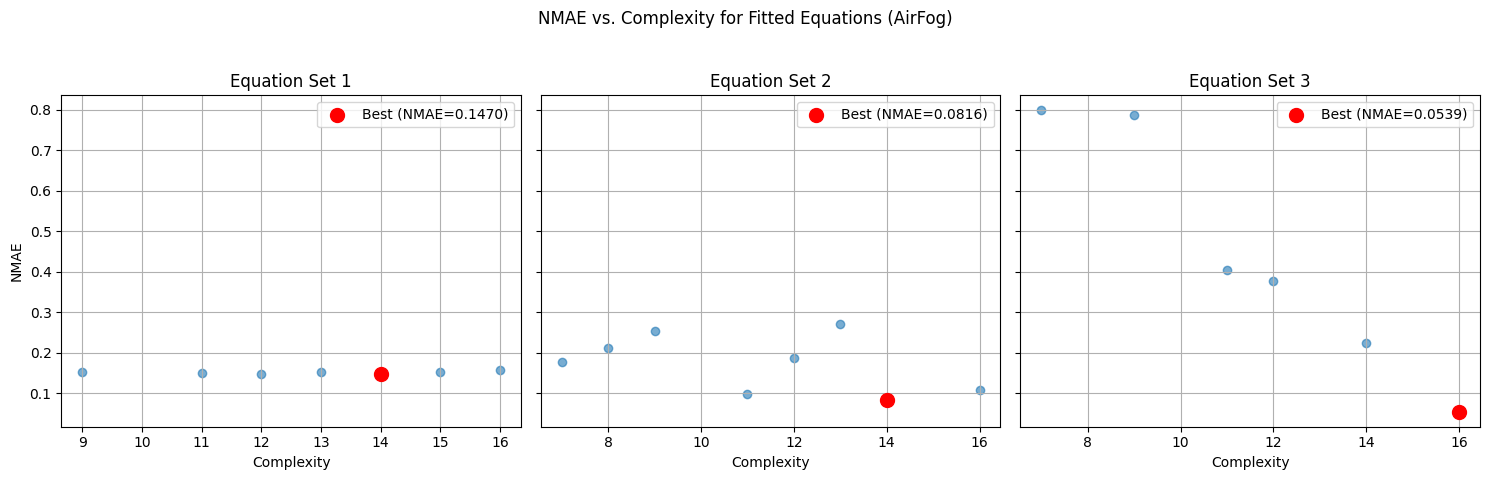

Experiment 3 finished.


In [7]:
import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "results/train"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

    with open(f"{directory_path}/run{i+1}.json", 'w') as json_file:
        json.dump(results, json_file, indent=2)

In [1]:
from helper import format_and_parse_expression_matrix, format_expressions

llm_array_output = '\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1^2 + c_1 \\cdot \\log(x_2) + c_2 \\cdot (x_4 + x_5 + x_6)", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2^3 + c_2 \\cdot \\sqrt{x_3}", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_4^2"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1 \\cdot x_2 + c_1 \\cdot x_3", \\\\\n"c_0 \\cdot x_1^2 + c_1 \\cdot x_2^2 + c_2 \\cdot x_3", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot \\log(x_3)"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"1 / (1 + \\exp(-(c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3)))", \\\\\n"\\min(1, \\max(0, c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3))", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3"\n\\end{array}\n\\right] \\]'
llm_bmatrix_output = """\\[
\\begin{bmatrix}
\\text{Pattern 1:} & \\left[ \\text{"x1^2 + x2*x3"}, \\, \\text{"\\log(x1 + x2) + \\sqrt{x3}"}, \\, \\text{"x1*x2 + \\frac{x3}{x1}"} \\right] \\\\
\\text{Pattern 2:} & \\left[ \\text{"x1 + x3"}, \\, \\text{"\\exp(x1) - x2"}, \\, \\text{"x1*x3 - \\log(x2)"} \\right] \\\\
\\text{Pattern 3:} & \\left[ \\text{"\\frac{1}{1 + \\exp(-x1)}"}, \\, \\text{"\\min(1, \\max(0, x1 + x2 - x3))"}, \\, \\text{"\\frac{x1}{1 + x3}"} \\right]
\\end{bmatrix}
\\]"""
llm_align_output = '\\[ \n\\begin{align*}\n\\text{Pattern 1:} \\\\\n& y1 = c_0 \\cdot x1^2 + c_1 \\cdot movavg(x2, 3) + c_2 \\cdot log(x4 + x5), \\\\\n& y2 = c_0 \\cdot x1 \\cdot x2 + c_1 \\cdot x3^2 + c_2 \\cdot sqrt(x6), \\\\\n& y3 = c_0 \\cdot log(x1 + x2) + c_1 \\cdot movavg(x5, 2) + c_2 \\cdot x4 \\cdot x6; \\\\\n\\text{Pattern 2:} \\\\\n& y1 = c_0 \\cdot x1 \\cdot x3 + c_1 \\cdot sqrt(x2), \\\\\n& y2 = c_0 \\cdot x1^2 + c_1 \\cdot x3^2 + c_2 \\cdot movavg(x1, 4), \\\\\n& y3 = c_0 \\cdot log(x1) + c_1 \\cdot x2 \\cdot x3; \\\\\n\\text{Pattern 3:} \\\\\n& y1 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot x2 + c_2 \\cdot x3))}, \\\\\n& y2 = \\min(1, \\max(0, c_0 \\cdot x1^2 + c_1 \\cdot x2 + c_2 \\cdot \\log(x3))), \\\\\n& y3 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot \\sqrt{x2) + c_2 \\cdot x3))}.\n\\end{align*}\n\\]'

# Parse the LLM output
parsed_matrix = format_and_parse_expression_matrix(llm_align_output)
# Print the parsed matrix
for row in parsed_matrix:
    print("Parsed Row:")
    print(row)
    print("Formatted Row:")
    print(format_expressions(row))
    print("\n")


Parsed Row:
['c[0] \\cdot x1^2 + c[1] \\cdot movavg(x2, 3) + c[2] \\cdot log(x4 + x5)', 'c[0] \\cdot x1 \\cdot x2 + c[1] \\cdot x3^2 + c[2] \\cdot sqrt(x6)', 'c[0] \\cdot log(x1 + x2) + c[1] \\cdot movavg(x5, 2) + c[2] \\cdot x4 \\cdot x6']
Formatted Row:
['c[0]*x1**2+c[1]*movavg(2, 3)+c[2]*log(x4+x5)', 'c[0]*x1*x2+c[1]*x3**2+c[2]*sqrt(x6)', 'c[0]*log(x1+x2)+c[1]*movavg(5, 2)+c[2]*x4*x6']


Parsed Row:
['c[0] \\cdot x1 \\cdot x3 + c[1] \\cdot sqrt(x2)', 'c[0] \\cdot x1^2 + c[1] \\cdot x3^2 + c[2] \\cdot movavg(x1, 4)', 'c[0] \\cdot log(x1) + c[1] \\cdot x2 \\cdot x3']
Formatted Row:
['c[0]*x1*x3+c[1]*sqrt(x2)', 'c[0]*x1**2+c[1]*x3**2+c[2]*movavg(1, 4)', 'c[0]*log(x1)+c[1]*x2*x3']


Parsed Row:
['(1) / (1 + \\exp(-(c[0] \\cdot x1 + c[1] \\cdot x2 + c[2] \\cdot x3)))', '\\min(1, \\max(0, c[0] \\cdot x1^2 + c[1] \\cdot x2 + c[2] \\cdot \\log(x3)))', '(1) / (1 + \\exp(-(c[0] \\cdot x1 + c[1] \\cdot \\sqrt{x2) + c[2] \\cdot x3))).']
Formatted Row:
['(1)/(1+exp(-(c[0]*x1+c[1]*x2+c[2]*x3)))',